In [1]:
# Cell 1: Environment and GPU check

import sys
import platform
from pathlib import Path

print("Python executable:", sys.executable)
print("Python version:", sys.version)
print("Platform:", platform.platform())

try:
    import torch
    
    print("\nPyTorch version:", torch.__version__)
    print("CUDA available:", torch.cuda.is_available())
    
    if torch.cuda.is_available():
        print("CUDA version used by PyTorch:", torch.version.cuda)
        print("GPU name:", torch.cuda.get_device_name(0))
        print("GPU memory allocated GB:", round(torch.cuda.memory_allocated(0) / 1024**3, 3))
        print("GPU memory reserved GB:", round(torch.cuda.memory_reserved(0) / 1024**3, 3))
    else:
        print("CUDA is not available in this notebook environment.")
        
except ImportError as error:
    print("PyTorch is not installed or not available in this environment.")
    print(error)

Python executable: d:\Projects\evidence_fashion_recommender\.venv\Scripts\python.exe
Python version: 3.11.15 (main, Jun  2 2026, 22:29:49) [MSC v.1944 64 bit (AMD64)]
Platform: Windows-10-10.0.26200-SP0

PyTorch version: 2.11.0+cu128
CUDA available: True
CUDA version used by PyTorch: 12.8
GPU name: NVIDIA GeForce RTX 5070 Ti
GPU memory allocated GB: 0.0
GPU memory reserved GB: 0.0


In [2]:
# Cell 2: Project folders and notebook paths

from pathlib import Path

PROJECT_ROOT = Path.cwd()

DATA_DIR = PROJECT_ROOT / "data"
RAW_DATA_DIR = DATA_DIR / "raw"
PROCESSED_DATA_DIR = DATA_DIR / "processed"
KB_DIR = DATA_DIR / "kb"

OUTPUTS_DIR = PROJECT_ROOT / "outputs"
EMBEDDINGS_DIR = OUTPUTS_DIR / "embeddings"
INDEXES_DIR = OUTPUTS_DIR / "indexes"
RESULTS_DIR = OUTPUTS_DIR / "results"
FIGURES_DIR = OUTPUTS_DIR / "figures"

folders = [
    DATA_DIR,
    RAW_DATA_DIR,
    PROCESSED_DATA_DIR,
    KB_DIR,
    OUTPUTS_DIR,
    EMBEDDINGS_DIR,
    INDEXES_DIR,
    RESULTS_DIR,
    FIGURES_DIR,
]

for folder in folders:
    folder.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("\nCreated/verified folders:")
for folder in folders:
    print("-", folder.relative_to(PROJECT_ROOT))

Project root: d:\Projects\evidence_fashion_recommender

Created/verified folders:
- data
- data\raw
- data\processed
- data\kb
- outputs
- outputs\embeddings
- outputs\indexes
- outputs\results
- outputs\figures


In [3]:
# Cell 3: Core library imports

import os
import json
import random
import math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from tqdm.auto import tqdm

from datasets import load_dataset

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

print("Core imports loaded successfully.")
print("Ready for Stage 0: real dataset loading and inspection.")

Core imports loaded successfully.
Ready for Stage 0: real dataset loading and inspection.


In [4]:
# Cell 4: Load real Polyvore-style dataset from Hugging Face

DATASET_NAME = "Marqo/polyvore"

print(f"Loading dataset: {DATASET_NAME}")

dataset = load_dataset(DATASET_NAME)

print("\nDataset loaded successfully.")
print("Available splits:")
print(dataset)

print("\nSplit names:")
print(list(dataset.keys()))

Loading dataset: Marqo/polyvore

Dataset loaded successfully.
Available splits:
DatasetDict({
    data: Dataset({
        features: ['image', 'category', 'text', 'item_ID'],
        num_rows: 94096
    })
})

Split names:
['data']


In [5]:
# Cell 5: Inspect dataset structure and raw examples

split_names = list(dataset.keys())
main_split_name = split_names[0]

print("Using first split for initial inspection:", main_split_name)

main_split = dataset[main_split_name]

print("\nNumber of rows in selected split:", len(main_split))

print("\nColumn names:")
print(main_split.column_names)

print("\nFeature types:")
print(main_split.features)

print("\nFirst raw example:")
first_example = main_split[0]

for key, value in first_example.items():
    value_type = type(value)
    
    if isinstance(value, str):
        preview = value[:300]
    elif isinstance(value, (list, tuple)):
        preview = value[:3]
    else:
        preview = value
        
    print(f"\n{key}")
    print("Type:", value_type)
    print("Preview:", preview)

print("\nFirst 3 rows as a small pandas preview:")
display(main_split.select(range(min(3, len(main_split)))).to_pandas())

Using first split for initial inspection: data

Number of rows in selected split: 94096

Column names:
['image', 'category', 'text', 'item_ID']

Feature types:
{'image': Image(mode=None, decode=True), 'category': Value('string'), 'text': Value('string'), 'item_ID': Value('string')}

First raw example:

image
Type: <class 'PIL.JpegImagePlugin.JpegImageFile'>
Preview: <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=274x400 at 0x2778702B110>

category
Type: <class 'str'>
Preview: Day Dresses

text
Type: <class 'str'>
Preview: tibi knit long sleeve dress

item_ID
Type: <class 'str'>
Preview: 100002074_1

First 3 rows as a small pandas preview:


,image,category,text,item_ID
0,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x01\x00H\x00H\x00\x00\xff\xdb\x00C\x00\x03\x02\x02\x03\x02\x02\...,Day Dresses,tibi knit long sleeve dress,100002074_1
1,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x01\x00H\x00H\x00\x00\xff\xdb\x00C\x00\x03\x02\x02\x03\x02\x02\...,Boots,michael kors leather over-the-knee boots,100002074_2
2,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x01\x00H\x00H\x00\x00\xff\xdb\x00C\x00\x03\x02\x02\x03\x02\x02\...,Handbags,givenchy leather medium antigona duffel black,100002074_3


In [6]:
# Cell 6: Convert selected split to DataFrame and inspect basic statistics

items_df_raw = main_split.to_pandas()

print("Raw DataFrame shape:", items_df_raw.shape)

print("\nColumns:")
print(list(items_df_raw.columns))

print("\nData types:")
display(items_df_raw.dtypes.to_frame("dtype"))

print("\nMissing values per column:")
missing_summary = (
    items_df_raw
    .isna()
    .sum()
    .sort_values(ascending=False)
    .to_frame("missing_count")
)

missing_summary["missing_percent"] = (
    missing_summary["missing_count"] / len(items_df_raw) * 100
).round(2)

display(missing_summary)

print("\nPossible ID columns:")
possible_id_columns = [
    column for column in items_df_raw.columns
    if "id" in column.lower()
]
print(possible_id_columns)

print("\nPossible category columns:")
possible_category_columns = [
    column for column in items_df_raw.columns
    if any(keyword in column.lower() for keyword in ["category", "cat", "type"])
]
print(possible_category_columns)

print("\nPossible text/metadata columns:")
possible_text_columns = [
    column for column in items_df_raw.columns
    if any(keyword in column.lower() for keyword in ["title", "text", "description", "name", "metadata"])
]
print(possible_text_columns)

print("\nPreview:")
display(items_df_raw.head())

Raw DataFrame shape: (94096, 4)

Columns:
['image', 'category', 'text', 'item_ID']

Data types:


,dtype
image,object
category,str
text,str
item_ID,str



Missing values per column:


,missing_count,missing_percent
image,0,0.0
category,0,0.0
text,0,0.0
item_ID,0,0.0



Possible ID columns:
['item_ID']

Possible category columns:
['category']

Possible text/metadata columns:
['text']

Preview:


,image,category,text,item_ID
0,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x01\x00H\x00H\x00\x00\xff\xdb\x00C\x00\x03\x02\x02\x03\x02\x02\...,Day Dresses,tibi knit long sleeve dress,100002074_1
1,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x01\x00H\x00H\x00\x00\xff\xdb\x00C\x00\x03\x02\x02\x03\x02\x02\...,Boots,michael kors leather over-the-knee boots,100002074_2
2,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x01\x00H\x00H\x00\x00\xff\xdb\x00C\x00\x03\x02\x02\x03\x02\x02\...,Handbags,givenchy leather medium antigona duffel black,100002074_3
3,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x01\x00H\x00H\x00\x00\xff\xdb\x00C\x00\x03\x02\x02\x03\x02\x02\...,Sunglasses,bottega veneta acetate leather sunglasses,100002074_4
4,"{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x01\x01,\x01,\x00\x00\xff\xdb\x00C\x00\x03\x02\x02\x03\x02\x02\...",Floral Decor,pier imports stem,100002074_5


In [7]:
# Cell 7: Build clean item table with outfit IDs

items_df = items_df_raw.copy()

items_df["item_ID"] = items_df["item_ID"].astype(str)
items_df["category"] = items_df["category"].astype(str)
items_df["text"] = items_df["text"].astype(str)

# Marqo/polyvore item_ID format appears to be: outfitID_itemPosition
# Example: 100002074_1 -> outfit_ID = 100002074, item_position = 1
id_parts = items_df["item_ID"].str.rsplit("_", n=1, expand=True)

items_df["outfit_ID"] = id_parts[0]
items_df["item_position"] = pd.to_numeric(id_parts[1], errors="coerce")

# Clean text field for later embedding
items_df["item_text"] = (
    items_df["category"].fillna("") 
    + " | " 
    + items_df["text"].fillna("")
)

# Reorder useful metadata columns first
metadata_columns = ["item_ID", "outfit_ID", "item_position", "category", "text", "item_text", "image"]
items_df = items_df[metadata_columns]

print("Clean item table shape:", items_df.shape)
print("\nPreview:")
display(items_df.head(10))

print("\nNumber of item_ID duplicates:", items_df["item_ID"].duplicated().sum())
print("Number of rows with missing outfit_ID:", items_df["outfit_ID"].isna().sum())
print("Number of rows with missing item_position:", items_df["item_position"].isna().sum())

Clean item table shape: (94096, 7)

Preview:


,item_ID,outfit_ID,item_position,category,text,item_text,image
0,100002074_1,100002074,1,Day Dresses,tibi knit long sleeve dress,Day Dresses | tibi knit long sleeve dress,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x01\x00H\x00H\x00\x00\xff\xdb\x00C\x00\x03\x02\x02\x03\x02\x02\...
1,100002074_2,100002074,2,Boots,michael kors leather over-the-knee boots,Boots | michael kors leather over-the-knee boots,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x01\x00H\x00H\x00\x00\xff\xdb\x00C\x00\x03\x02\x02\x03\x02\x02\...
2,100002074_3,100002074,3,Handbags,givenchy leather medium antigona duffel black,Handbags | givenchy leather medium antigona duffel black,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x01\x00H\x00H\x00\x00\xff\xdb\x00C\x00\x03\x02\x02\x03\x02\x02\...
3,100002074_4,100002074,4,Sunglasses,bottega veneta acetate leather sunglasses,Sunglasses | bottega veneta acetate leather sunglasses,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x01\x00H\x00H\x00\x00\xff\xdb\x00C\x00\x03\x02\x02\x03\x02\x02\...
4,100002074_5,100002074,5,Floral Decor,pier imports stem,Floral Decor | pier imports stem,"{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x01\x01,\x01,\x00\x00\xff\xdb\x00C\x00\x03\x02\x02\x03\x02\x02\..."
5,100002074_7,100002074,7,Coats,miranda coat,Coats | miranda coat,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x01\x00H\x00H\x00\x00\xff\xdb\x00C\x00\x03\x02\x02\x03\x02\x02\...
6,100010727_1,100010727,1,Blazers,three pocket blazer,Blazers | three pocket blazer,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x01\x00`\x00`\x00\x00\xff\xdb\x00C\x00\x03\x02\x02\x03\x02\x02\...
7,100010727_2,100010727,2,Skinny Jeans,givenchy skinny jean,Skinny Jeans | givenchy skinny jean,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x01\x00`\x00`\x00\x00\xff\xdb\x00C\x00\x03\x02\x02\x03\x02\x02\...
8,100010727_4,100010727,4,Watches,guess black silver-tone chronograph watch,Watches | guess black silver-tone chronograph watch,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x01\x00H\x00H\x00\x00\xff\xdb\x00C\x00\x03\x02\x02\x03\x02\x02\...
9,100010727_5,100010727,5,Sunglasses,ray-ban original wayfarer sunglasses,Sunglasses | ray-ban original wayfarer sunglasses,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x01\x00H\x00H\x00\x00\xff\xdb\x00C\x00\x03\x02\x02\x03\x02\x02\...



Number of item_ID duplicates: 0
Number of rows with missing outfit_ID: 0
Number of rows with missing item_position: 0


Dataset statistics
------------------
Number of items: 94096
Number of outfits: 21587
Number of unique categories: 377
Average outfit size: 4.359
Median outfit size: 4.0
Minimum outfit size: 1
Maximum outfit size: 8

Outfit size distribution:


,outfit_size_stats
count,21587.000000
mean,4.358920
std,1.739006
min,1.000000
25%,3.000000
50%,4.000000
75%,6.000000
max,8.000000



Top 20 categories:


,category,item_count
0,Earrings,3606
1,Shoulder Bags,3525
2,Necklaces,3379
3,Tops,2851
4,Sandals,2689
5,Day Dresses,2525
6,Bracelets & Bangles,2505
7,Pumps,2422
8,Clutches,2377
9,Ankle Booties,2355


<Figure size 1000x500 with 0 Axes>

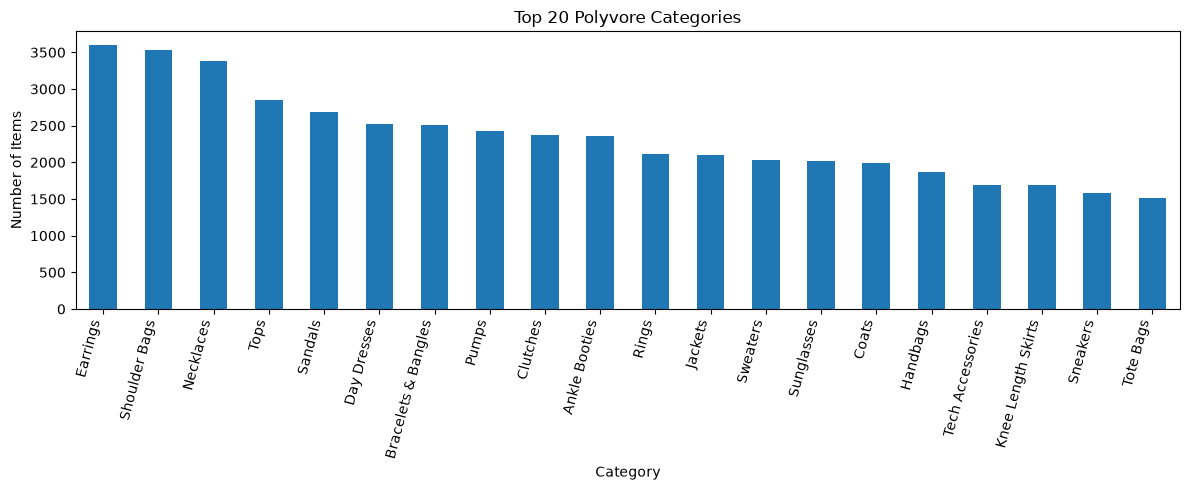

In [8]:
# Cell 8: Dataset statistics

num_items = len(items_df)
num_outfits = items_df["outfit_ID"].nunique()
num_categories = items_df["category"].nunique()

outfit_sizes = (
    items_df
    .groupby("outfit_ID")
    .size()
    .rename("outfit_size")
    .reset_index()
)

category_counts = (
    items_df["category"]
    .value_counts()
    .rename_axis("category")
    .reset_index(name="item_count")
)

print("Dataset statistics")
print("------------------")
print("Number of items:", num_items)
print("Number of outfits:", num_outfits)
print("Number of unique categories:", num_categories)
print("Average outfit size:", round(outfit_sizes["outfit_size"].mean(), 3))
print("Median outfit size:", outfit_sizes["outfit_size"].median())
print("Minimum outfit size:", outfit_sizes["outfit_size"].min())
print("Maximum outfit size:", outfit_sizes["outfit_size"].max())

print("\nOutfit size distribution:")
display(outfit_sizes["outfit_size"].describe().to_frame("outfit_size_stats"))

print("\nTop 20 categories:")
display(category_counts.head(20))

plt.figure(figsize=(10, 5))
category_counts.head(20).plot(
    x="category",
    y="item_count",
    kind="bar",
    legend=False,
    figsize=(12, 5)
)
plt.title("Top 20 Polyvore Categories")
plt.xlabel("Category")
plt.ylabel("Number of Items")
plt.xticks(rotation=75, ha="right")
plt.tight_layout()
plt.show()

Displaying sample outfit: 100002074


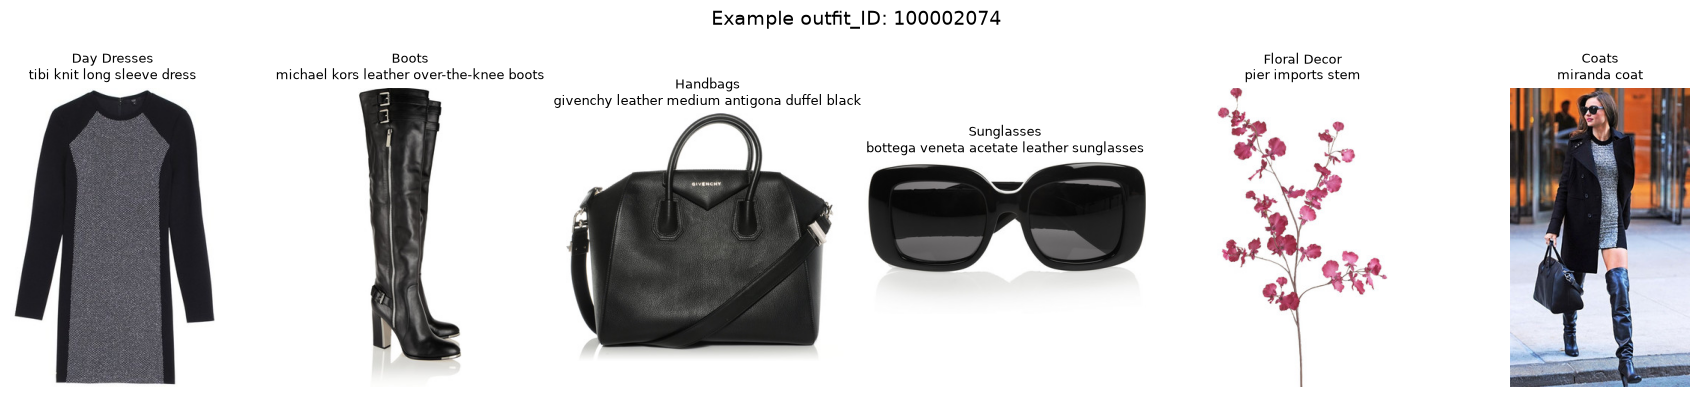

,item_ID,outfit_ID,item_position,category,text
0,100002074_1,100002074,1,Day Dresses,tibi knit long sleeve dress
1,100002074_2,100002074,2,Boots,michael kors leather over-the-knee boots
2,100002074_3,100002074,3,Handbags,givenchy leather medium antigona duffel black
3,100002074_4,100002074,4,Sunglasses,bottega veneta acetate leather sunglasses
4,100002074_5,100002074,5,Floral Decor,pier imports stem
5,100002074_7,100002074,7,Coats,miranda coat


In [9]:
# Cell 9: Display one real outfit with item images

def display_outfit(outfit_id, max_items=8):
    """
    Display all items from one outfit using the original Hugging Face dataset images.
    """
    outfit_rows = (
        items_df[items_df["outfit_ID"] == str(outfit_id)]
        .sort_values("item_position")
        .head(max_items)
    )
    
    if outfit_rows.empty:
        print(f"No outfit found for outfit_ID={outfit_id}")
        return
    
    n_items = len(outfit_rows)
    fig, axes = plt.subplots(1, n_items, figsize=(3 * n_items, 4))
    
    if n_items == 1:
        axes = [axes]
    
    for axis, (_, row) in zip(axes, outfit_rows.iterrows()):
        dataset_index = row.name
        
        # Use the original Hugging Face dataset object so image decoding stays reliable
        image = main_split[int(dataset_index)]["image"]
        
        axis.imshow(image)
        axis.axis("off")
        axis.set_title(
            f"{row['category']}\n{row['text'][:45]}",
            fontsize=9
        )
    
    plt.suptitle(f"Example outfit_ID: {outfit_id}", fontsize=14)
    plt.tight_layout()
    plt.show()
    
    display(outfit_rows[["item_ID", "outfit_ID", "item_position", "category", "text"]])


# Pick the first outfit from the dataset for a deterministic example
sample_outfit_id = items_df.loc[0, "outfit_ID"]

print("Displaying sample outfit:", sample_outfit_id)
display_outfit(sample_outfit_id)

In [10]:
# Cell 10: Inspect all fine-grained categories

all_categories = sorted(items_df["category"].dropna().unique())

print("Number of unique fine-grained categories:", len(all_categories))
print("\nAll categories:")
for index, category in enumerate(all_categories, start=1):
    print(f"{index:03d}. {category}")

category_counts_full = (
    items_df["category"]
    .value_counts()
    .rename_axis("category")
    .reset_index(name="item_count")
)

print("\nTop 50 fine-grained categories:")
display(category_counts_full.head(50))

Number of unique fine-grained categories: 377

All categories:
001. Accent Chairs
002. Accent Tables
003. Accessories
004. Activewear
005. Activewear Jackets
006. Activewear Pants
007. Activewear Shorts
008. Activewear Skirts
009. Activewear Tank Tops
010. Activewear Tops
011. Ankle Booties
012. Aprons
013. Armoires
014. Athletic Shoes
015. Baby
016. Baby Bedding
017. Backpacks
018. Bags
019. Bags & Cases
020. Bakeware
021. Bar Cabinets
022. Bar Tools
023. Barstools
024. Bath
025. Bath & Body
026. Bath Accessories
027. Bath Rugs & Mats
028. Bath Towels
029. Beach Towels
030. Beauty Accessories
031. Beauty Products
032. Bed Accessories
033. Bed Pillows
034. Bedding
035. Beds
036. Bedspreads
037. Belts
038. Benches
039. Bikini Bottoms
040. Bikini Tops
041. Bikinis
042. Blankets
043. Blazers
044. Blouses
045. Blow Dryers & Irons
046. Blush
047. Body Art
048. Body Cleansers
049. Body Moisturizers
050. Bookcases
051. Books
052. Bootcut Jeans
053. Boots
054. Bow Ties
055. Boyfriend Jeans
056

,category,item_count
0,Earrings,3606
1,Shoulder Bags,3525
2,Necklaces,3379
3,Tops,2851
4,Sandals,2689
5,Day Dresses,2525
6,Bracelets & Bangles,2505
7,Pumps,2422
8,Clutches,2377
9,Ankle Booties,2355


In [11]:
# Cell 11: Define broad category mapping rules

BROAD_CATEGORY_RULES = {
    "tops": [
        "top", "tops", "shirt", "shirts", "blouse", "blouses",
        "tee", "t-shirt", "tank", "camisole", "camisoles",
        "sweater", "sweaters", "sweatshirt", "sweatshirts",
        "cardigan", "cardigans", "hoodie", "hoodies",
        "tunic", "tunics", "polo"
    ],
    "bottoms": [
        "jean", "jeans", "trouser", "trousers", "pants",
        "leggings", "shorts", "skirt", "skirts",
        "culottes", "joggers"
    ],
    "shoes": [
        "shoe", "shoes", "boot", "boots", "sneaker", "sneakers",
        "sandal", "sandals", "pump", "pumps", "heel", "heels",
        "flat", "flats", "loafer", "loafers", "oxford", "oxfords",
        "mule", "mules", "slipper", "slippers", "espadrille", "espadrilles"
    ],
    "outerwear": [
        "coat", "coats", "jacket", "jackets", "blazer", "blazers",
        "parka", "parkas", "poncho", "ponchos", "vest", "vests",
        "cape", "capes", "trench"
    ],
    "accessories": [
        "bag", "bags", "handbag", "handbags", "clutch", "clutches",
        "tote", "totes", "backpack", "backpacks", "satchel", "satchels",
        "earring", "earrings", "necklace", "necklaces",
        "bracelet", "bracelets", "bangle", "bangles",
        "ring", "rings", "watch", "watches",
        "sunglasses", "eyewear", "glasses",
        "belt", "belts", "scarf", "scarves",
        "hat", "hats", "beanie", "beanies",
        "wallet", "wallets"
    ],
}


def map_to_broad_category(category):
    """
    Map a fine-grained Polyvore category to one broad thesis category.
    Returns 'other' when the category does not match the target groups.
    """
    category_lower = str(category).lower()
    
    for broad_category, keywords in BROAD_CATEGORY_RULES.items():
        for keyword in keywords:
            if keyword in category_lower:
                return broad_category
    
    return "other"


# Preview mapping on all unique categories
category_mapping_preview = pd.DataFrame({
    "category": all_categories
})

category_mapping_preview["broad_category"] = category_mapping_preview["category"].apply(map_to_broad_category)

print("Broad category mapping preview:")
display(category_mapping_preview)

print("\nNumber of fine categories mapped to each broad category:")
display(
    category_mapping_preview["broad_category"]
    .value_counts()
    .rename_axis("broad_category")
    .reset_index(name="num_fine_categories")
)

Broad category mapping preview:


,category,broad_category
0,Accent Chairs,other
1,Accent Tables,other
2,Accessories,other
3,Activewear,other
4,Activewear Jackets,outerwear
...,...,...
372,Watches,accessories
373,Wedding Dresses,other
374,Wide Leg Jeans,bottoms
375,Window Blinds,other



Number of fine categories mapped to each broad category:


,broad_category,num_fine_categories
0,other,255
1,accessories,39
2,bottoms,25
3,shoes,25
4,tops,23
5,outerwear,10


In [12]:
# Cell 12: Apply broad category mapping and create target item table

items_df["broad_category"] = items_df["category"].apply(map_to_broad_category)

broad_category_counts = (
    items_df["broad_category"]
    .value_counts()
    .rename_axis("broad_category")
    .reset_index(name="item_count")
)

print("Item distribution after broad category mapping:")
display(broad_category_counts)

target_broad_categories = [
    "tops",
    "bottoms",
    "shoes",
    "outerwear",
    "accessories",
]

target_items_df = (
    items_df[items_df["broad_category"].isin(target_broad_categories)]
    .copy()
    .reset_index(drop=False)
    .rename(columns={"index": "original_dataset_index"})
)

print("Original item count:", len(items_df))
print("Target item count:", len(target_items_df))
print("Removed/other item count:", len(items_df) - len(target_items_df))
print("Target item percentage:", round(len(target_items_df) / len(items_df) * 100, 2), "%")

print("\nTarget broad category distribution:")
target_broad_counts = (
    target_items_df["broad_category"]
    .value_counts()
    .rename_axis("broad_category")
    .reset_index(name="item_count")
)

display(target_broad_counts)

print("\nExamples from each broad category:")
for broad_category in target_broad_categories:
    print(f"\n--- {broad_category.upper()} ---")
    display(
        target_items_df[target_items_df["broad_category"] == broad_category]
        [["item_ID", "outfit_ID", "category", "broad_category", "text"]]
        .head(5)
    )

Item distribution after broad category mapping:


,broad_category,item_count
0,accessories,29566
1,other,26572
2,shoes,12635
3,tops,10915
4,bottoms,9247
5,outerwear,5161


Original item count: 94096
Target item count: 67524
Removed/other item count: 26572
Target item percentage: 71.76 %

Target broad category distribution:


,broad_category,item_count
0,accessories,29566
1,shoes,12635
2,tops,10915
3,bottoms,9247
4,outerwear,5161



Examples from each broad category:

--- TOPS ---


...

,item_ID,outfit_ID,category,broad_category,text
0,100002074_2,100002074,Boots,shoes,michael kors leather over-the-knee boots
11,100050716_2,100050716,Sandals,shoes,beige crystal sandals
13,100060207_2,100060207,Pumps,shoes,givenchy striped print pumps yellow grey black
25,100089693_2,100089693,Pumps,shoes,peep-toe black platform high heels
30,100095342_4,100095342,Ankle Booties,shoes,acne short fur lined leather boots



--- OUTERWEAR ---


,item_ID,outfit_ID,category,broad_category,text
3,100002074_7,100002074,Coats,outerwear,miranda coat
4,100010727_1,100010727,Blazers,outerwear,three pocket blazer
28,100095342_2,100095342,Vests,outerwear,fake fur waistcoat
39,100111991_2,100111991,Coats,outerwear,paul joe long fit peacoat
61,100173896_2,100173896,Coats,outerwear,fashion heather coat



--- ACCESSORIES ---


,item_ID,outfit_ID,category,broad_category,text
1,100002074_3,100002074,Handbags,accessories,givenchy leather medium antigona duffel black
2,100002074_4,100002074,Sunglasses,accessories,bottega veneta acetate leather sunglasses
6,100010727_4,100010727,Watches,accessories,guess black silver-tone chronograph watch
7,100010727_5,100010727,Sunglasses,accessories,ray-ban original wayfarer sunglasses
9,100029003_2,100029003,Handbags,accessories,phillip lim red leather satchel


In [13]:
# Cell 13: Add query-only dress category

def map_to_query_category(category):
    """
    Map fine-grained categories for query items.
    This includes the five recommendation groups plus 'dresses' as a valid input/query category.
    """
    category_lower = str(category).lower()
    
    dress_keywords = [
        "dress", "dresses", "gown", "gowns"
    ]
    
    for keyword in dress_keywords:
        if keyword in category_lower:
            return "dresses"
    
    return map_to_broad_category(category)


items_df["query_category"] = items_df["category"].apply(map_to_query_category)

query_category_counts = (
    items_df["query_category"]
    .value_counts()
    .rename_axis("query_category")
    .reset_index(name="item_count")
)

print("Query category distribution:")
display(query_category_counts)

query_allowed_categories = [
    "tops",
    "bottoms",
    "shoes",
    "outerwear",
    "accessories",
    "dresses",
]

query_items_df = (
    items_df[items_df["query_category"].isin(query_allowed_categories)]
    .copy()
    .reset_index(drop=False)
    .rename(columns={"index": "original_dataset_index"})
)

print("Original item count:", len(items_df))
print("Valid query item count:", len(query_items_df))
print("Valid query item percentage:", round(len(query_items_df) / len(items_df) * 100, 2), "%")

print("\nDress examples now available as query items:")
display(
    query_items_df[query_items_df["query_category"] == "dresses"]
    [["item_ID", "outfit_ID", "category", "query_category", "text"]]
    .head(10)
)

Query category distribution:


,query_category,item_count
0,accessories,29566
1,other,22276
2,shoes,12601
3,tops,10871
4,bottoms,9217
5,outerwear,5161
6,dresses,4404


Original item count: 94096
Valid query item count: 71820
Valid query item percentage: 76.33 %

Dress examples now available as query items:


,item_ID,outfit_ID,category,query_category,text
0,100002074_1,100002074,Day Dresses,dresses,tibi knit long sleeve dress
10,100029003_1,100029003,Day Dresses,dresses,rochas dress
15,100060207_1,100060207,Day Dresses,dresses,atelier pleat shift tunic
28,100079699_1,100079699,Day Dresses,dresses,topshop strap back slip dress
29,100089693_1,100089693,Day Dresses,dresses,stripe skinny bodycon mini dress
44,100111991_1,100111991,Day Dresses,dresses,phase eight coral cable swing dress
107,100285829_2,100285829,Dressers,dresses,chest please us
131,100443358_1,100443358,Day Dresses,dresses,marni short boxy fur dress
163,100631293_1,100631293,Cocktail Dresses,dresses,topshop wrap mesh skater dress
168,100658683_1,100658683,Cocktail Dresses,dresses,club l cut mesh peplum dress


In [14]:
# Cell 14: Save processed metadata tables

processed_items_path = PROCESSED_DATA_DIR / "items_clean.parquet"
target_items_path = PROCESSED_DATA_DIR / "target_items.parquet"
query_items_path = PROCESSED_DATA_DIR / "query_items.parquet"
category_mapping_path = PROCESSED_DATA_DIR / "category_mapping_preview.csv"

# Do not save the image column into parquet metadata tables.
# Images remain accessible through the Hugging Face dataset using original_dataset_index.
items_metadata_to_save = items_df.drop(columns=["image"], errors="ignore")
target_metadata_to_save = target_items_df.drop(columns=["image"], errors="ignore")
query_metadata_to_save = query_items_df.drop(columns=["image"], errors="ignore")

items_metadata_to_save.to_parquet(processed_items_path, index=False)
target_metadata_to_save.to_parquet(target_items_path, index=False)
query_metadata_to_save.to_parquet(query_items_path, index=False)
category_mapping_preview.to_csv(category_mapping_path, index=False)

print("Saved processed files:")
print("-", processed_items_path.relative_to(PROJECT_ROOT))
print("-", target_items_path.relative_to(PROJECT_ROOT))
print("-", query_items_path.relative_to(PROJECT_ROOT))
print("-", category_mapping_path.relative_to(PROJECT_ROOT))

print("\nSaved table shapes:")
print("items_clean:", items_metadata_to_save.shape)
print("target_items:", target_metadata_to_save.shape)
print("query_items:", query_metadata_to_save.shape)
print("category_mapping_preview:", category_mapping_preview.shape)

Saved processed files:
- data\processed\items_clean.parquet
- data\processed\target_items.parquet
- data\processed\query_items.parquet
- data\processed\category_mapping_preview.csv

Saved table shapes:
items_clean: (94096, 8)
target_items: (67524, 8)
query_items: (71820, 9)
category_mapping_preview: (377, 2)


In [15]:
# Cell 15: Check outfit coverage after category filtering

target_outfit_counts = (
    target_items_df
    .groupby("outfit_ID")
    .size()
    .rename("num_target_items")
    .reset_index()
)

query_outfit_counts = (
    query_items_df
    .groupby("outfit_ID")
    .size()
    .rename("num_query_items")
    .reset_index()
)

outfit_coverage_df = (
    outfit_sizes
    .merge(target_outfit_counts, on="outfit_ID", how="left")
    .merge(query_outfit_counts, on="outfit_ID", how="left")
)

outfit_coverage_df["num_target_items"] = outfit_coverage_df["num_target_items"].fillna(0).astype(int)
outfit_coverage_df["num_query_items"] = outfit_coverage_df["num_query_items"].fillna(0).astype(int)

usable_outfits_df = outfit_coverage_df[
    (outfit_coverage_df["num_query_items"] >= 1)
    & (outfit_coverage_df["num_target_items"] >= 2)
].copy()

print("Total outfits:", len(outfit_coverage_df))
print("Outfits with at least 1 valid query item and at least 2 target recommendation items:", len(usable_outfits_df))
print("Usable outfit percentage:", round(len(usable_outfits_df) / len(outfit_coverage_df) * 100, 2), "%")

print("\nCoverage statistics:")
display(
    outfit_coverage_df[
        ["outfit_size", "num_query_items", "num_target_items"]
    ].describe()
)

print("\nExample usable outfits:")
display(usable_outfits_df.head(10))

Total outfits: 21587
Outfits with at least 1 valid query item and at least 2 target recommendation items: 17660
Usable outfit percentage: 81.81 %

Coverage statistics:


,outfit_size,num_query_items,num_target_items
count,21587.000000,21587.000000,21587.000000
mean,4.358920,3.327002,3.127994
std,1.739006,1.723292,1.737597
min,1.000000,0.000000,0.000000
25%,3.000000,2.000000,2.000000
50%,4.000000,3.000000,3.000000
75%,6.000000,4.000000,4.000000
max,8.000000,8.000000,8.000000



Example usable outfits:


,outfit_ID,outfit_size,num_target_items,num_query_items
0,100002074,6,4,5
1,100010727,7,5,5
2,100029003,3,2,3
3,100050716,4,2,2
5,100060207,6,5,6
6,100077218,7,7,7
8,100089693,3,2,3
9,100095342,6,6,6
10,100099673,8,6,6
11,100111991,8,6,7


In [16]:
# Cell 16: Analyze broad category composition inside outfits
# RUN AFTER CELLS 1-15 / RERUN ONLY IF CATEGORY MAPPING CHANGES

outfit_broad_composition = (
    target_items_df
    .groupby("outfit_ID")["broad_category"]
    .agg(
        num_target_items="count",
        num_unique_broad_categories="nunique",
        broad_categories=lambda values: sorted(values.unique())
    )
    .reset_index()
)

print("Outfit broad-category composition shape:", outfit_broad_composition.shape)

print("\nBroad-category diversity per outfit:")
display(
    outfit_broad_composition["num_unique_broad_categories"]
    .describe()
    .to_frame("num_unique_broad_categories")
)

print("\nDistribution of number of broad categories per outfit:")
broad_diversity_counts = (
    outfit_broad_composition["num_unique_broad_categories"]
    .value_counts()
    .sort_index()
    .rename_axis("num_unique_broad_categories")
    .reset_index(name="num_outfits")
)
display(broad_diversity_counts)

print("\nExample outfits with many broad categories:")
display(
    outfit_broad_composition
    .sort_values(["num_unique_broad_categories", "num_target_items"], ascending=False)
    .head(10)
)

Outfit broad-category composition shape: (20148, 4)

Broad-category diversity per outfit:


,num_unique_broad_categories
count,20148.000000
mean,2.617977
std,1.129536
min,1.000000
25%,2.000000
50%,3.000000
75%,3.000000
max,5.000000



Distribution of number of broad categories per outfit:


,num_unique_broad_categories,num_outfits
0,1,3658
1,2,6195
2,3,5483
3,4,3810
4,5,1002



Example outfits with many broad categories:


,outfit_ID,num_target_items,num_unique_broad_categories,broad_categories
32,100445477,8,5,"[accessories, bottoms, outerwear, shoes, tops]"
161,102665177,8,5,"[accessories, bottoms, outerwear, shoes, tops]"
218,103867145,8,5,"[accessories, bottoms, outerwear, shoes, tops]"
298,105081429,8,5,"[accessories, bottoms, outerwear, shoes, tops]"
338,105881838,8,5,"[accessories, bottoms, outerwear, shoes, tops]"
365,106100743,8,5,"[accessories, bottoms, outerwear, shoes, tops]"
391,106345656,8,5,"[accessories, bottoms, outerwear, shoes, tops]"
429,106813596,8,5,"[accessories, bottoms, outerwear, shoes, tops]"
777,111059798,8,5,"[accessories, bottoms, outerwear, shoes, tops]"
832,111632032,8,5,"[accessories, bottoms, outerwear, shoes, tops]"


Broad category co-occurrence matrix:


,tops,bottoms,shoes,outerwear,accessories
tops,10101,6172,6354,2561,7888
bottoms,6172,9040,5716,2445,7044
shoes,6354,5716,12346,3316,9993
outerwear,2561,2445,3316,5066,4035
accessories,7888,7044,9993,4035,16194


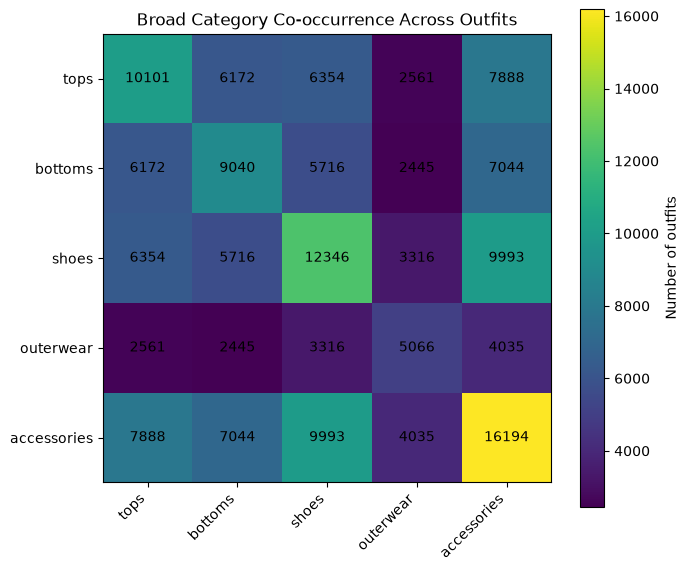

In [17]:
# Cell 17: Category co-occurrence matrix
# RUN AFTER CELLS 1-16 / RERUN ONLY IF CATEGORY MAPPING CHANGES

broad_categories_order = [
    "tops",
    "bottoms",
    "shoes",
    "outerwear",
    "accessories",
]

cooccurrence_matrix = pd.DataFrame(
    0,
    index=broad_categories_order,
    columns=broad_categories_order,
    dtype=int
)

for _, row in outfit_broad_composition.iterrows():
    categories_in_outfit = set(row["broad_categories"])
    
    for category_a in broad_categories_order:
        for category_b in broad_categories_order:
            if category_a in categories_in_outfit and category_b in categories_in_outfit:
                cooccurrence_matrix.loc[category_a, category_b] += 1

print("Broad category co-occurrence matrix:")
display(cooccurrence_matrix)

plt.figure(figsize=(7, 6))
plt.imshow(cooccurrence_matrix.values)
plt.xticks(range(len(broad_categories_order)), broad_categories_order, rotation=45, ha="right")
plt.yticks(range(len(broad_categories_order)), broad_categories_order)
plt.title("Broad Category Co-occurrence Across Outfits")
plt.colorbar(label="Number of outfits")

for row_index in range(len(broad_categories_order)):
    for col_index in range(len(broad_categories_order)):
        plt.text(
            col_index,
            row_index,
            cooccurrence_matrix.values[row_index, col_index],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

Testing display helper with outfit_ID: 100002074


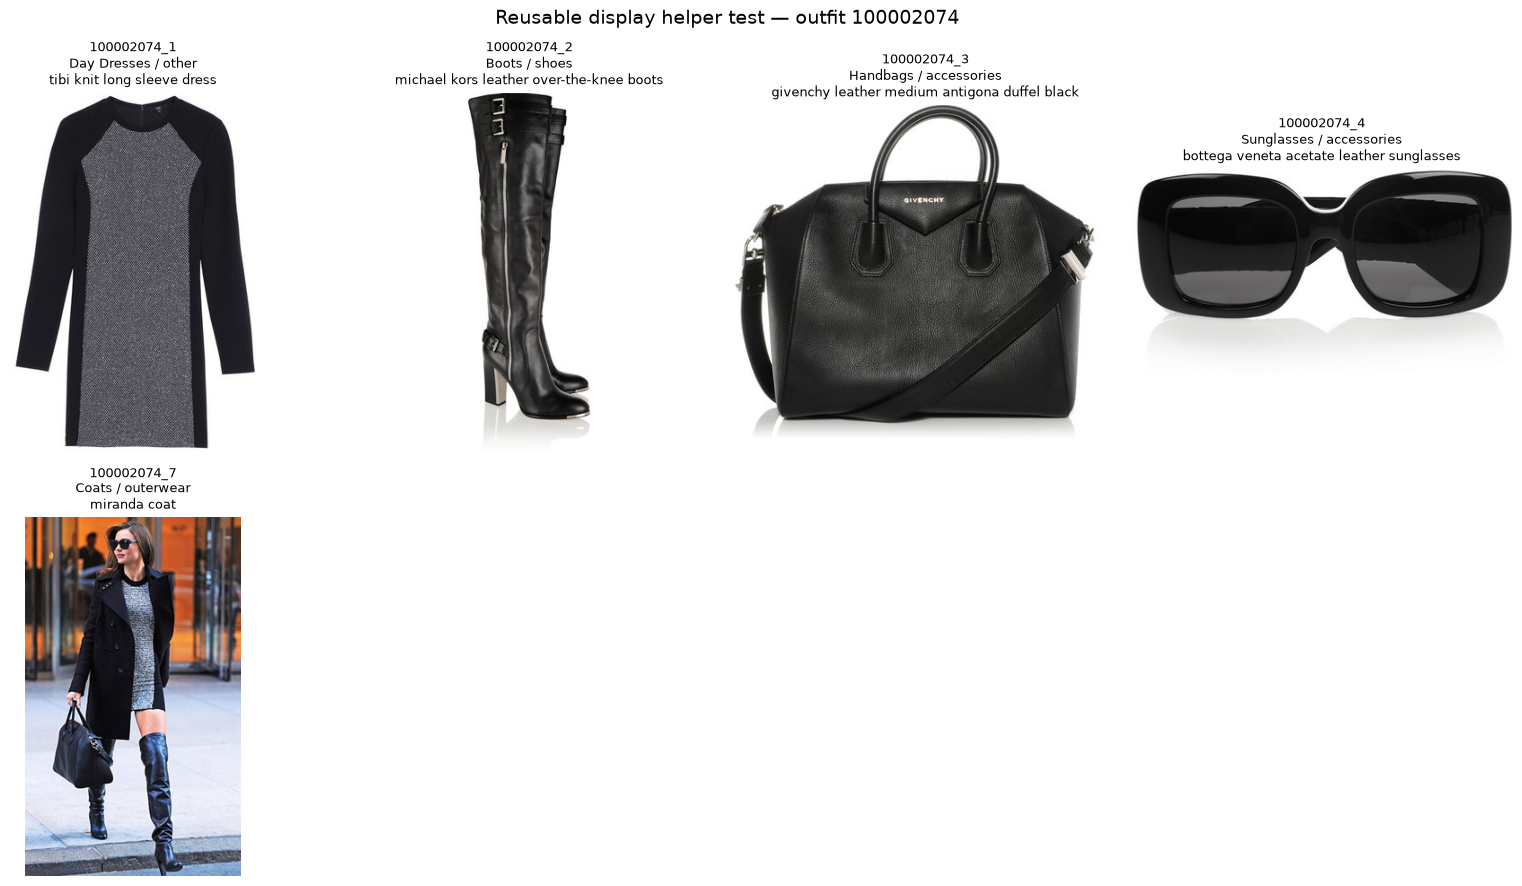

,item_ID,outfit_ID,item_position,category,broad_category,query_category,text
0,100002074_1,100002074,1,Day Dresses,other,dresses,tibi knit long sleeve dress
1,100002074_2,100002074,2,Boots,shoes,shoes,michael kors leather over-the-knee boots
2,100002074_3,100002074,3,Handbags,accessories,accessories,givenchy leather medium antigona duffel black
3,100002074_4,100002074,4,Sunglasses,accessories,accessories,bottega veneta acetate leather sunglasses
4,100002074_7,100002074,7,Coats,outerwear,outerwear,miranda coat


In [18]:
# Cell 18: Reusable visual display helper for items
# RUN EVERY SESSION AFTER DATASET AND METADATA ARE LOADED

def display_items_grid(items_table, title="Items", max_items=8, image_index_column="original_dataset_index"):
    """
    Display a grid of item images using original Hugging Face dataset indexes.
    Expected columns include item_ID, category, text, and original_dataset_index.
    """
    if items_table.empty:
        print("No items to display.")
        return
    
    display_table = items_table.head(max_items).copy()
    n_items = len(display_table)
    
    cols = min(n_items, 4)
    rows = math.ceil(n_items / cols)
    
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4.5 * rows))
    
    if rows == 1 and cols == 1:
        axes = np.array([[axes]])
    elif rows == 1:
        axes = np.array([axes])
    elif cols == 1:
        axes = np.array([[axis] for axis in axes])
    
    axes_flat = axes.flatten()
    
    for axis in axes_flat:
        axis.axis("off")
    
    for axis, (_, row) in zip(axes_flat, display_table.iterrows()):
        dataset_index = int(row[image_index_column])
        image = main_split[dataset_index]["image"]
        
        axis.imshow(image)
        axis.axis("off")
        
        label = (
            f"{row['item_ID']}\n"
            f"{row['category']}"
        )
        
        if "broad_category" in row:
            label += f" / {row['broad_category']}"
        elif "query_category" in row:
            label += f" / {row['query_category']}"
        
        label += f"\n{str(row['text'])[:45]}"
        
        axis.set_title(label, fontsize=9)
    
    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()
    
    table_columns = [
        column for column in [
            "item_ID",
            "outfit_ID",
            "item_position",
            "category",
            "broad_category",
            "query_category",
            "text",
        ]
        if column in display_table.columns
    ]
    
    display(display_table[table_columns])


# Test the helper on one usable outfit
example_usable_outfit_id = usable_outfits_df.iloc[0]["outfit_ID"]

example_items = (
    query_items_df[query_items_df["outfit_ID"] == example_usable_outfit_id]
    .sort_values("item_position")
)

print("Testing display helper with outfit_ID:", example_usable_outfit_id)
display_items_grid(
    example_items,
    title=f"Reusable display helper test — outfit {example_usable_outfit_id}",
    max_items=8
)

In [19]:
# Cell 19: Load text embedding model
# RUN EVERY SESSION BEFORE EMBEDDING OR RETRIEVAL CELLS

from sentence_transformers import SentenceTransformer

TEXT_EMBEDDING_MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"

device = "cuda" if torch.cuda.is_available() else "cpu"

print("Loading text embedding model:", TEXT_EMBEDDING_MODEL_NAME)
print("Device:", device)

text_embedding_model = SentenceTransformer(
    TEXT_EMBEDDING_MODEL_NAME,
    device=device
)

sample_texts = target_items_df["item_text"].head(5).tolist()

sample_embeddings = text_embedding_model.encode(
    sample_texts,
    normalize_embeddings=True,
    convert_to_numpy=True,
    show_progress_bar=False
)

print("Model loaded successfully.")
print("Sample texts:", sample_texts)
print("Sample embedding shape:", sample_embeddings.shape)
print("Embedding dtype:", sample_embeddings.dtype)

Loading text embedding model: sentence-transformers/all-MiniLM-L6-v2
Device: cuda


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Model loaded successfully.
Sample texts: ['Boots | michael kors leather over-the-knee boots', 'Handbags | givenchy leather medium antigona duffel black', 'Sunglasses | bottega veneta acetate leather sunglasses', 'Coats | miranda coat', 'Blazers | three pocket blazer']
Sample embedding shape: (5, 384)
Embedding dtype: float32


In [20]:
# Cell 20: Compute or load target item text embeddings
# RUN EVERY SESSION; FIRST RUN COMPUTES, LATER RUNS LOAD CACHE

target_embeddings_path = EMBEDDINGS_DIR / "target_text_embeddings_all_minilm_l6_v2.npy"
target_metadata_path = PROCESSED_DATA_DIR / "target_items_for_embeddings.parquet"

# Save matching metadata so embedding row order is always reproducible.
target_items_for_embeddings = target_items_df.reset_index(drop=True).copy()
target_items_for_embeddings.to_parquet(target_metadata_path, index=False)

if target_embeddings_path.exists():
    print("Loading cached target embeddings from:")
    print(target_embeddings_path.relative_to(PROJECT_ROOT))
    
    target_text_embeddings = np.load(target_embeddings_path)
    
else:
    print("Computing target item text embeddings.")
    print("Number of target items:", len(target_items_for_embeddings))
    
    target_texts = target_items_for_embeddings["item_text"].fillna("").tolist()
    
    target_text_embeddings = text_embedding_model.encode(
        target_texts,
        batch_size=256,
        normalize_embeddings=True,
        convert_to_numpy=True,
        show_progress_bar=True
    )
    
    np.save(target_embeddings_path, target_text_embeddings)
    
    print("Saved target embeddings to:")
    print(target_embeddings_path.relative_to(PROJECT_ROOT))

print("Target embedding matrix shape:", target_text_embeddings.shape)
print("Target metadata shape:", target_items_for_embeddings.shape)

assert len(target_items_for_embeddings) == target_text_embeddings.shape[0], (
    "Metadata rows and embedding rows do not match."
)

print("Target embeddings are ready.")

Loading cached target embeddings from:
outputs\embeddings\target_text_embeddings_all_minilm_l6_v2.npy
Target embedding matrix shape: (67524, 384)
Target metadata shape: (67524, 9)
Target embeddings are ready.


In [21]:
# Cell 21: Build category-aware FAISS indexes
# RUN EVERY SESSION AFTER TARGET EMBEDDINGS ARE AVAILABLE

import faiss

embedding_dim = target_text_embeddings.shape[1]

category_indexes = {}
category_row_lookup = {}

for broad_category in target_broad_categories:
    category_rows = target_items_for_embeddings.index[
        target_items_for_embeddings["broad_category"] == broad_category
    ].to_numpy()
    
    category_embeddings = target_text_embeddings[category_rows].astype("float32")
    
    # Embeddings are already normalized, so inner product = cosine similarity.
    index = faiss.IndexFlatIP(embedding_dim)
    index.add(category_embeddings)
    
    category_indexes[broad_category] = index
    category_row_lookup[broad_category] = category_rows
    
    print(
        f"{broad_category:12s} | "
        f"items: {len(category_rows):6d} | "
        f"index vectors: {index.ntotal:6d}"
    )

print("\nBuilt category-aware FAISS indexes.")
print("Available target categories:", list(category_indexes.keys()))

tops         | items:  10915 | index vectors:  10915
bottoms      | items:   9247 | index vectors:   9247
shoes        | items:  12635 | index vectors:  12635
outerwear    | items:   5161 | index vectors:   5161
accessories  | items:  29566 | index vectors:  29566

Built category-aware FAISS indexes.
Available target categories: ['tops', 'bottoms', 'shoes', 'outerwear', 'accessories']


In [22]:
# Cell 22: Build query text representation
# RUN EVERY SESSION AFTER TEXT EMBEDDING MODEL IS LOADED

def get_query_item_by_id(query_item_id):
    """
    Get one query item from query_items_df by item_ID.
    """
    matches = query_items_df[query_items_df["item_ID"] == str(query_item_id)]
    
    if matches.empty:
        raise ValueError(f"query_item_id not found in query_items_df: {query_item_id}")
    
    return matches.iloc[0].copy()


def build_query_text(query_item_row=None, user_text="", target_category=None):
    """
    Build the baseline text query used for embedding retrieval.
    """
    query_parts = []
    
    if query_item_row is not None:
        query_parts.extend([
            f"Query item category: {query_item_row.get('category', '')}",
            f"Query item type: {query_item_row.get('query_category', '')}",
            f"Query item description: {query_item_row.get('text', '')}",
        ])
    
    if user_text:
        query_parts.append(f"User request: {user_text}")
    
    if target_category:
        query_parts.append(f"Recommended category: {target_category}")
    
    return " | ".join(query_parts)


# Test with a real query item from the first usable outfit
test_query_item_id = "100002074_1"
test_user_text = "recommend smart casual shoes"
test_target_category = "shoes"

test_query_item = get_query_item_by_id(test_query_item_id)

test_query_text = build_query_text(
    query_item_row=test_query_item,
    user_text=test_user_text,
    target_category=test_target_category
)

print("Test query item:")
display(test_query_item.to_frame("value"))

print("\nConstructed query text:")
print(test_query_text)

Test query item:


,value
original_dataset_index,0
item_ID,100002074_1
outfit_ID,100002074
item_position,1
category,Day Dresses
text,tibi knit long sleeve dress
item_text,Day Dresses | tibi knit long sleeve dress
image,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x01\x00H\x00H\x00\x00\xff\xdb\x00C\x00\x03\x02\x02\x03\x02\x02\...
broad_category,other
query_category,dresses



Constructed query text:
Query item category: Day Dresses | Query item type: dresses | Query item description: tibi knit long sleeve dress | User request: recommend smart casual shoes | Recommended category: shoes


In [23]:
# Cell 23: Category-aware baseline retrieval function
# RUN EVERY SESSION AFTER FAISS INDEXES ARE BUILT

def retrieve_baseline_recommendations(
    query_item_id=None,
    user_text="",
    target_category="shoes",
    top_k=5,
    exclude_same_outfit=True,
):
    """
    Retrieve top-K recommendations from the requested broad category
    using text embedding cosine similarity.
    """
    if target_category not in category_indexes:
        raise ValueError(
            f"Unknown target_category={target_category}. "
            f"Available categories: {list(category_indexes.keys())}"
        )
    
    query_item_row = None
    
    if query_item_id is not None:
        query_item_row = get_query_item_by_id(query_item_id)
    
    query_text = build_query_text(
        query_item_row=query_item_row,
        user_text=user_text,
        target_category=target_category
    )
    
    query_embedding = text_embedding_model.encode(
        [query_text],
        normalize_embeddings=True,
        convert_to_numpy=True,
        show_progress_bar=False
    ).astype("float32")
    
    # Retrieve more than top_k first so we can remove the query item/outfit if needed.
    search_k = min(top_k * 20, category_indexes[target_category].ntotal)
    
    scores, local_indices = category_indexes[target_category].search(
        query_embedding,
        search_k
    )
    
    global_rows = category_row_lookup[target_category][local_indices[0]]
    
    results = target_items_for_embeddings.iloc[global_rows].copy()
    results["embedding_score"] = scores[0]
    
    if query_item_row is not None:
        results = results[results["item_ID"] != query_item_row["item_ID"]]
        
        if exclude_same_outfit:
            results = results[results["outfit_ID"] != query_item_row["outfit_ID"]]
    
    results = results.head(top_k).reset_index(drop=True)
    
    return {
        "query_text": query_text,
        "query_item": query_item_row,
        "target_category": target_category,
        "results": results,
    }


baseline_test = retrieve_baseline_recommendations(
    query_item_id="100002074_1",
    user_text="recommend smart casual shoes",
    target_category="shoes",
    top_k=5,
)

print("Query text used for retrieval:")
print(baseline_test["query_text"])

print("\nBaseline recommendations:")
display(
    baseline_test["results"][
        ["item_ID", "outfit_ID", "category", "broad_category", "text", "embedding_score"]
    ]
)

Query text used for retrieval:
Query item category: Day Dresses | Query item type: dresses | Query item description: tibi knit long sleeve dress | User request: recommend smart casual shoes | Recommended category: shoes

Baseline recommendations:


,item_ID,outfit_ID,category,broad_category,text,embedding_score
0,208659502_2,208659502,Sandals,shoes,satin toe bow sandals rhinestone platform white wedding evening shoes high heel wedding evening evening shoes high h...,0.490115
1,213208045_3,213208045,Shoes,shoes,burberry shoes accessories metallic giant check cashmere scarf,0.486860
2,190117110_8,190117110,Shoes,shoes,fashion shoes,0.461421
3,201283503_2,201283503,Flats,shoes,elegant bow zipper design flat shoes women,0.460544
4,104608755_4,104608755,Shoes,shoes,fashion lace,0.459101


Query text:
Query item category: Day Dresses | Query item type: dresses | Query item description: tibi knit long sleeve dress | User request: recommend smart casual shoes | Recommended category: shoes

Query item:


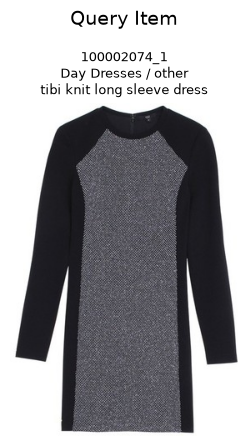

,item_ID,outfit_ID,item_position,category,broad_category,query_category,text
0,100002074_1,100002074,1,Day Dresses,other,dresses,tibi knit long sleeve dress



Baseline recommendations:


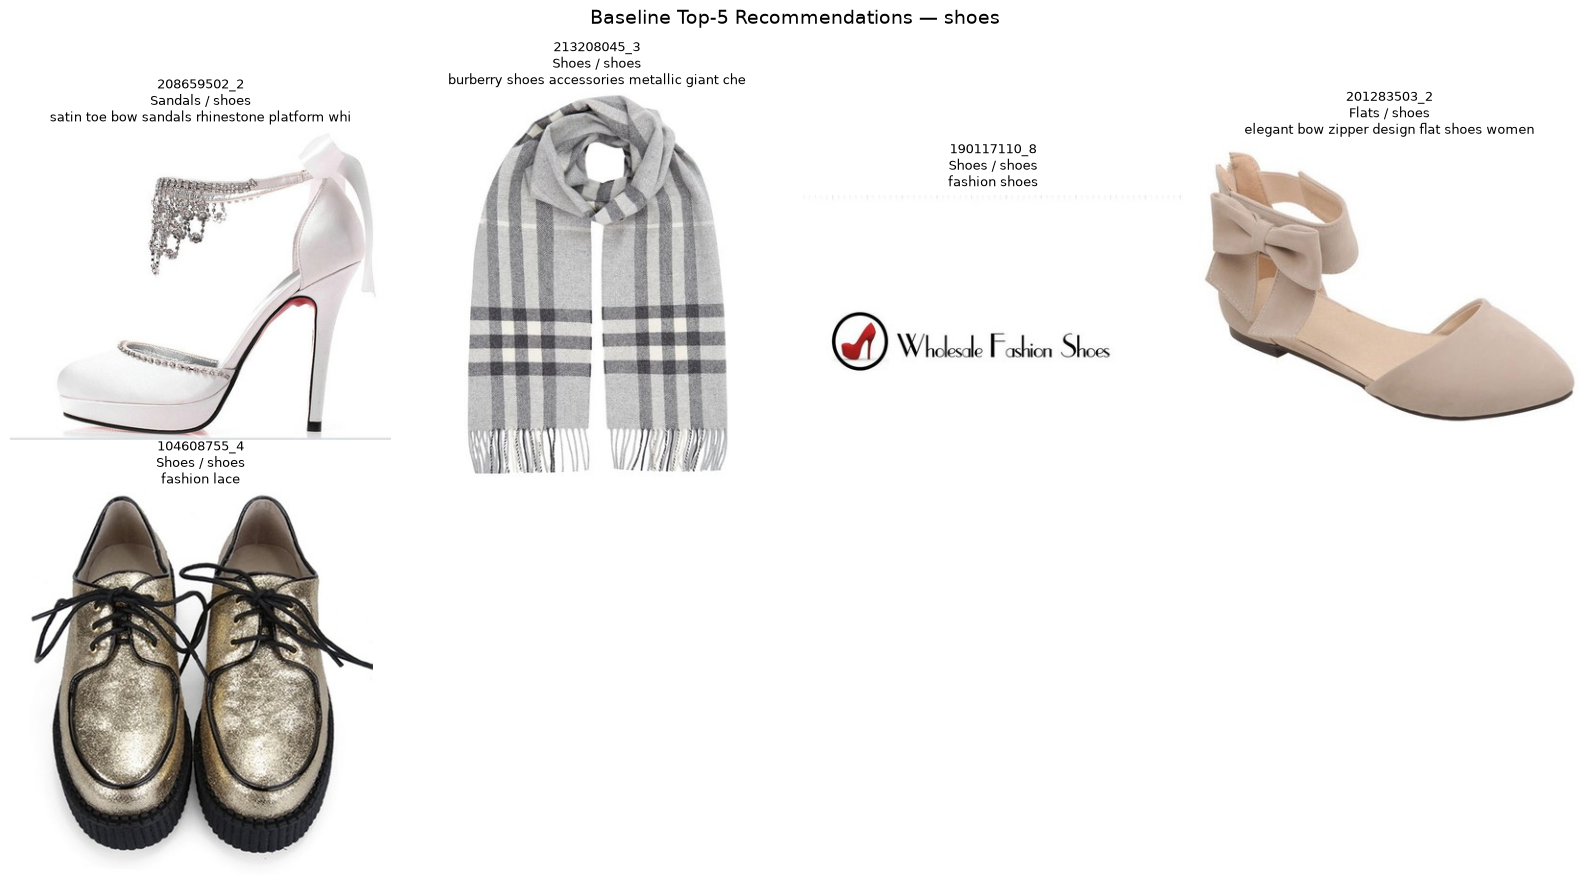

,item_ID,outfit_ID,item_position,category,broad_category,text
0,208659502_2,208659502,2,Sandals,shoes,satin toe bow sandals rhinestone platform white wedding evening shoes high heel wedding evening evening shoes high h...
1,213208045_3,213208045,3,Shoes,shoes,burberry shoes accessories metallic giant check cashmere scarf
2,190117110_8,190117110,8,Shoes,shoes,fashion shoes
3,201283503_2,201283503,2,Flats,shoes,elegant bow zipper design flat shoes women
4,104608755_4,104608755,4,Shoes,shoes,fashion lace


,item_ID,outfit_ID,category,broad_category,text,embedding_score
0,208659502_2,208659502,Sandals,shoes,satin toe bow sandals rhinestone platform white wedding evening shoes high heel wedding evening evening shoes high h...,0.490115
1,213208045_3,213208045,Shoes,shoes,burberry shoes accessories metallic giant check cashmere scarf,0.486860
2,190117110_8,190117110,Shoes,shoes,fashion shoes,0.461421
3,201283503_2,201283503,Flats,shoes,elegant bow zipper design flat shoes women,0.460544
4,104608755_4,104608755,Shoes,shoes,fashion lace,0.459101


In [24]:
# Cell 24: Visualize baseline recommendations
# RUN EVERY SESSION WHEN TESTING RECOMMENDATION OUTPUTS

def display_baseline_recommendation_result(retrieval_result, max_items=5):
    """
    Display query item and baseline recommendations.
    """
    query_item = retrieval_result["query_item"]
    recommendations = retrieval_result["results"]
    
    print("Query text:")
    print(retrieval_result["query_text"])
    
    if query_item is not None:
        query_item_table = pd.DataFrame([query_item])
        
        print("\nQuery item:")
        display_items_grid(
            query_item_table,
            title="Query Item",
            max_items=1,
            image_index_column="original_dataset_index"
        )
    
    print("\nBaseline recommendations:")
    display_items_grid(
        recommendations,
        title=f"Baseline Top-{len(recommendations)} Recommendations — {retrieval_result['target_category']}",
        max_items=max_items,
        image_index_column="original_dataset_index"
    )
    
    display(
        recommendations[
            ["item_ID", "outfit_ID", "category", "broad_category", "text", "embedding_score"]
        ]
    )


display_baseline_recommendation_result(
    baseline_test,
    max_items=5
)

In [25]:
# # Cell 25: Inspect suspicious category/text mismatches
# # RUN AFTER CELLS 1-24 / RERUN IF CATEGORY MAPPING OR CLEANING RULES CHANGE

# SUSPICIOUS_TERMS_BY_CATEGORY = {
#     "shoes": [
#         "scarf", "scarves", "bag", "handbag", "clutch", "tote", "wallet",
#         "necklace", "earrings", "bracelet", "ring", "watch", "sunglasses",
#         "case", "decor", "bedding", "chair", "table"
#     ],
#     "tops": [
#         "shoe", "shoes", "boot", "boots", "sandal", "sandals", "pump", "pumps",
#         "bag", "handbag", "necklace", "earrings", "bracelet", "ring",
#         "decor", "bedding", "chair", "table"
#     ],
#     "bottoms": [
#         "shoe", "shoes", "boot", "boots", "sandal", "sandals",
#         "bag", "handbag", "necklace", "earrings", "bracelet", "ring",
#         "decor", "bedding", "chair", "table"
#     ],
#     "outerwear": [
#         "shoe", "shoes", "boot", "boots", "sandal", "sandals",
#         "bag", "handbag", "necklace", "earrings", "bracelet", "ring",
#         "decor", "bedding", "chair", "table"
#     ],
#     "accessories": [
#         "dress", "dresses", "jeans", "pants", "trousers", "skirt", "shorts",
#         "coat", "jacket", "blazer", "shirt", "sweater"
#     ],
# }


# def contains_any_term(text, terms):
#     """
#     Return True if any suspicious term appears in the text.
#     Uses simple substring matching for transparent dataset auditing.
#     """
#     text_lower = str(text).lower()
#     return any(term in text_lower for term in terms)


# suspicious_rows = []

# for broad_category, suspicious_terms in SUSPICIOUS_TERMS_BY_CATEGORY.items():
#     category_subset = target_items_for_embeddings[
#         target_items_for_embeddings["broad_category"] == broad_category
#     ].copy()
    
#     category_subset["suspicious_reason"] = category_subset["text"].apply(
#         lambda value: ", ".join(
#             [term for term in suspicious_terms if term in str(value).lower()]
#         )
#     )
    
#     category_subset = category_subset[category_subset["suspicious_reason"] != ""]
#     suspicious_rows.append(category_subset)

# suspicious_items_df = pd.concat(suspicious_rows, ignore_index=True)

# print("Total target candidate items:", len(target_items_for_embeddings))
# print("Suspicious category/text mismatch items:", len(suspicious_items_df))
# print("Suspicious percentage:", round(len(suspicious_items_df) / len(target_items_for_embeddings) * 100, 2), "%")

# print("\nSuspicious count by broad category:")
# display(
#     suspicious_items_df["broad_category"]
#     .value_counts()
#     .rename_axis("broad_category")
#     .reset_index(name="suspicious_count")
# )

# print("\nSuspicious examples:")
# display(
#     suspicious_items_df[
#         ["item_ID", "outfit_ID", "category", "broad_category", "text", "suspicious_reason"]
#     ].head(50)
# )

In [26]:
# # Cell 26: Create cleaned candidate pool
# # RUN AFTER CELL 25 / RERUN IF CLEANING RULES CHANGE

# target_items_clean_df = target_items_for_embeddings.copy()

# target_items_clean_df["is_suspicious_category_text_mismatch"] = False
# target_items_clean_df["cleaning_reason"] = ""

# for broad_category, suspicious_terms in SUSPICIOUS_TERMS_BY_CATEGORY.items():
#     category_mask = target_items_clean_df["broad_category"] == broad_category
    
#     suspicious_mask = target_items_clean_df.loc[category_mask, "text"].apply(
#         lambda value: contains_any_term(value, suspicious_terms)
#     )
    
#     suspicious_indices = target_items_clean_df.loc[category_mask].index[suspicious_mask]
    
#     target_items_clean_df.loc[
#         suspicious_indices,
#         "is_suspicious_category_text_mismatch"
#     ] = True
    
#     target_items_clean_df.loc[
#         suspicious_indices,
#         "cleaning_reason"
#     ] = "category_text_mismatch"


# clean_target_items_for_embeddings = (
#     target_items_clean_df[
#         ~target_items_clean_df["is_suspicious_category_text_mismatch"]
#     ]
#     .copy()
#     .reset_index(drop=False)
#     .rename(columns={"index": "original_embedding_row"})
# )

# removed_candidates_df = (
#     target_items_clean_df[
#         target_items_clean_df["is_suspicious_category_text_mismatch"]
#     ]
#     .copy()
# )

# print("Original target candidates:", len(target_items_for_embeddings))
# print("Clean target candidates:", len(clean_target_items_for_embeddings))
# print("Removed candidates:", len(removed_candidates_df))
# print("Removed percentage:", round(len(removed_candidates_df) / len(target_items_for_embeddings) * 100, 2), "%")

# print("\nOriginal broad category counts:")
# display(
#     target_items_for_embeddings["broad_category"]
#     .value_counts()
#     .rename_axis("broad_category")
#     .reset_index(name="original_count")
# )

# print("\nClean broad category counts:")
# display(
#     clean_target_items_for_embeddings["broad_category"]
#     .value_counts()
#     .rename_axis("broad_category")
#     .reset_index(name="clean_count")
# )

# print("\nRemoved examples:")
# display(
#     removed_candidates_df[
#         ["item_ID", "outfit_ID", "category", "broad_category", "text", "cleaning_reason"]
#     ].head(50)
# )

# clean_target_metadata_path = PROCESSED_DATA_DIR / "target_items_clean.parquet"
# removed_candidates_path = PROCESSED_DATA_DIR / "removed_noisy_candidates.parquet"

# clean_target_items_for_embeddings.drop(columns=["image"], errors="ignore").to_parquet(
#     clean_target_metadata_path,
#     index=False
# )

# removed_candidates_df.drop(columns=["image"], errors="ignore").to_parquet(
#     removed_candidates_path,
#     index=False
# )

# print("\nSaved:")
# print("-", clean_target_metadata_path.relative_to(PROJECT_ROOT))
# print("-", removed_candidates_path.relative_to(PROJECT_ROOT))

In [27]:
# # Cell 27: Rebuild cleaned FAISS indexes and compare retrieval
# # RUN EVERY SESSION AFTER CLEANED CANDIDATE POOL AND TARGET EMBEDDINGS ARE READY

# clean_target_text_embeddings = target_text_embeddings[
#     clean_target_items_for_embeddings["original_embedding_row"].to_numpy()
# ]

# clean_category_indexes = {}
# clean_category_row_lookup = {}

# embedding_dim = clean_target_text_embeddings.shape[1]

# for broad_category in target_broad_categories:
#     category_rows = clean_target_items_for_embeddings.index[
#         clean_target_items_for_embeddings["broad_category"] == broad_category
#     ].to_numpy()
    
#     category_embeddings = clean_target_text_embeddings[category_rows].astype("float32")
    
#     index = faiss.IndexFlatIP(embedding_dim)
#     index.add(category_embeddings)
    
#     clean_category_indexes[broad_category] = index
#     clean_category_row_lookup[broad_category] = category_rows
    
#     print(
#         f"{broad_category:12s} | "
#         f"clean items: {len(category_rows):6d} | "
#         f"index vectors: {index.ntotal:6d}"
#     )


# def retrieve_clean_baseline_recommendations(
#     query_item_id=None,
#     user_text="",
#     target_category="shoes",
#     top_k=5,
#     exclude_same_outfit=True,
# ):
#     """
#     Retrieve top-K recommendations from the cleaned candidate pool.
#     """
#     if target_category not in clean_category_indexes:
#         raise ValueError(
#             f"Unknown target_category={target_category}. "
#             f"Available categories: {list(clean_category_indexes.keys())}"
#         )
    
#     query_item_row = None
    
#     if query_item_id is not None:
#         query_item_row = get_query_item_by_id(query_item_id)
    
#     query_text = build_query_text(
#         query_item_row=query_item_row,
#         user_text=user_text,
#         target_category=target_category
#     )
    
#     query_embedding = text_embedding_model.encode(
#         [query_text],
#         normalize_embeddings=True,
#         convert_to_numpy=True,
#         show_progress_bar=False
#     ).astype("float32")
    
#     search_k = min(top_k * 20, clean_category_indexes[target_category].ntotal)
    
#     scores, local_indices = clean_category_indexes[target_category].search(
#         query_embedding,
#         search_k
#     )
    
#     global_rows = clean_category_row_lookup[target_category][local_indices[0]]
    
#     results = clean_target_items_for_embeddings.iloc[global_rows].copy()
#     results["embedding_score"] = scores[0]
    
#     if query_item_row is not None:
#         results = results[results["item_ID"] != query_item_row["item_ID"]]
        
#         if exclude_same_outfit:
#             results = results[results["outfit_ID"] != query_item_row["outfit_ID"]]
    
#     results = results.head(top_k).reset_index(drop=True)
    
#     return {
#         "query_text": query_text,
#         "query_item": query_item_row,
#         "target_category": target_category,
#         "results": results,
#     }


# clean_baseline_test = retrieve_clean_baseline_recommendations(
#     query_item_id="100002074_1",
#     user_text="recommend smart casual shoes",
#     target_category="shoes",
#     top_k=5,
# )

# print("\nOriginal baseline recommendations:")
# display(
#     baseline_test["results"][
#         ["item_ID", "outfit_ID", "category", "broad_category", "text", "embedding_score"]
#     ]
# )

# print("\nCleaned baseline recommendations:")
# display(
#     clean_baseline_test["results"][
#         ["item_ID", "outfit_ID", "category", "broad_category", "text", "embedding_score"]
#     ]
# )

# print("\nVisual cleaned recommendations:")
# display_baseline_recommendation_result(clean_baseline_test, max_items=5)

In [28]:
# # Cell 28: Improved suspicious term matching with word boundaries
# # RUN AFTER CELLS 1-24 / RERUN IF CLEANING RULES CHANGE

# import re

# def contains_any_term_strict(text, terms):
#     """
#     Return matched suspicious terms using word-boundary matching.
#     This avoids false positives such as:
#     - ring inside fringe
#     - ring inside spring
#     - bag inside baggage-like longer words
#     """
#     text_lower = str(text).lower()
#     matched_terms = []
    
#     for term in terms:
#         term_lower = str(term).lower()
        
#         # Match phrase/word as a separate token or phrase.
#         pattern = r"(?<![a-zA-Z])" + re.escape(term_lower) + r"(?![a-zA-Z])"
        
#         if re.search(pattern, text_lower):
#             matched_terms.append(term)
    
#     return matched_terms


# strict_suspicious_rows = []

# for broad_category, suspicious_terms in SUSPICIOUS_TERMS_BY_CATEGORY.items():
#     category_subset = target_items_for_embeddings[
#         target_items_for_embeddings["broad_category"] == broad_category
#     ].copy()
    
#     category_subset["matched_suspicious_terms"] = category_subset["text"].apply(
#         lambda value: contains_any_term_strict(value, suspicious_terms)
#     )
    
#     category_subset["suspicious_reason"] = category_subset["matched_suspicious_terms"].apply(
#         lambda terms: ", ".join(terms)
#     )
    
#     category_subset = category_subset[category_subset["suspicious_reason"] != ""]
#     strict_suspicious_rows.append(category_subset)

# strict_suspicious_items_df = pd.concat(strict_suspicious_rows, ignore_index=True)

# print("Previous suspicious items:", len(suspicious_items_df))
# print("Strict suspicious items:", len(strict_suspicious_items_df))
# print("Strict suspicious percentage:", round(len(strict_suspicious_items_df) / len(target_items_for_embeddings) * 100, 2), "%")

# print("\nStrict suspicious count by broad category:")
# display(
#     strict_suspicious_items_df["broad_category"]
#     .value_counts()
#     .rename_axis("broad_category")
#     .reset_index(name="strict_suspicious_count")
# )

# print("\nStrict suspicious examples:")
# display(
#     strict_suspicious_items_df[
#         ["item_ID", "outfit_ID", "category", "broad_category", "text", "suspicious_reason"]
#     ].head(50)
# )

# print("\nChecking previous false-positive examples containing fringe/spring/string:")
# false_positive_check = target_items_for_embeddings[
#     target_items_for_embeddings["text"].str.lower().str.contains(
#         "fringe|fringed|spring|string",
#         na=False,
#         regex=True
#     )
# ].copy()

# false_positive_check["strict_matches"] = false_positive_check.apply(
#     lambda row: contains_any_term_strict(
#         row["text"],
#         SUSPICIOUS_TERMS_BY_CATEGORY.get(row["broad_category"], [])
#     ),
#     axis=1
# )

# display(
#     false_positive_check[
#         ["item_ID", "category", "broad_category", "text", "strict_matches"]
#     ].head(30)
# )

In [29]:
# # Cell 29: Recreate cleaned candidate pool with strict rules
# # RUN AFTER CELL 28 / RERUN IF CLEANING RULES CHANGE

# target_items_clean_df = target_items_for_embeddings.copy()

# target_items_clean_df["is_suspicious_category_text_mismatch"] = False
# target_items_clean_df["cleaning_reason"] = ""
# target_items_clean_df["matched_suspicious_terms"] = ""

# for broad_category, suspicious_terms in SUSPICIOUS_TERMS_BY_CATEGORY.items():
#     category_mask = target_items_clean_df["broad_category"] == broad_category
    
#     matched_terms_series = target_items_clean_df.loc[category_mask, "text"].apply(
#         lambda value: contains_any_term_strict(value, suspicious_terms)
#     )
    
#     suspicious_mask = matched_terms_series.apply(lambda terms: len(terms) > 0)
#     suspicious_indices = target_items_clean_df.loc[category_mask].index[suspicious_mask]
    
#     target_items_clean_df.loc[
#         suspicious_indices,
#         "is_suspicious_category_text_mismatch"
#     ] = True
    
#     target_items_clean_df.loc[
#         suspicious_indices,
#         "cleaning_reason"
#     ] = "strict_category_text_mismatch"
    
#     target_items_clean_df.loc[
#         suspicious_indices,
#         "matched_suspicious_terms"
#     ] = matched_terms_series[suspicious_mask].apply(lambda terms: ", ".join(terms)).values


# clean_target_items_for_embeddings = (
#     target_items_clean_df[
#         ~target_items_clean_df["is_suspicious_category_text_mismatch"]
#     ]
#     .copy()
#     .reset_index(drop=False)
#     .rename(columns={"index": "original_embedding_row"})
# )

# removed_candidates_df = (
#     target_items_clean_df[
#         target_items_clean_df["is_suspicious_category_text_mismatch"]
#     ]
#     .copy()
# )

# print("Original target candidates:", len(target_items_for_embeddings))
# print("Clean target candidates after strict filtering:", len(clean_target_items_for_embeddings))
# print("Removed candidates after strict filtering:", len(removed_candidates_df))
# print("Removed percentage:", round(len(removed_candidates_df) / len(target_items_for_embeddings) * 100, 2), "%")

# print("\nRemoved count by broad category:")
# display(
#     removed_candidates_df["broad_category"]
#     .value_counts()
#     .rename_axis("broad_category")
#     .reset_index(name="removed_count")
# )

# print("\nRemoved examples after strict filtering:")
# display(
#     removed_candidates_df[
#         ["item_ID", "outfit_ID", "category", "broad_category", "text", "matched_suspicious_terms", "cleaning_reason"]
#     ].head(50)
# )

# clean_target_metadata_path = PROCESSED_DATA_DIR / "target_items_clean.parquet"
# removed_candidates_path = PROCESSED_DATA_DIR / "removed_noisy_candidates.parquet"

# clean_target_items_for_embeddings.drop(columns=["image"], errors="ignore").to_parquet(
#     clean_target_metadata_path,
#     index=False
# )

# removed_candidates_df.drop(columns=["image"], errors="ignore").to_parquet(
#     removed_candidates_path,
#     index=False
# )

# print("\nSaved strict-cleaned files:")
# print("-", clean_target_metadata_path.relative_to(PROJECT_ROOT))
# print("-", removed_candidates_path.relative_to(PROJECT_ROOT))

In [30]:
# # Cell 30: Detect likely blank or low-information images
# # RUN AFTER CLEAN CANDIDATE POOL IS CREATED / RERUN IF IMAGE QUALITY RULES CHANGE

# def compute_image_quality_stats(dataset_index, resize_to=(64, 64)):
#     """
#     Compute simple image-quality statistics for a dataset image.
#     These are not perfect, but useful for auditing blank or low-information images.
#     """
#     image = main_split[int(dataset_index)]["image"].convert("RGB")
#     image_small = image.resize(resize_to)
    
#     array = np.asarray(image_small).astype(np.float32) / 255.0
    
#     mean_pixel = float(array.mean())
#     std_pixel = float(array.std())
    
#     # Very bright pixels are common in product photos, but too many can mean blank background.
#     white_pixel_ratio = float((array > 0.95).all(axis=2).mean())
    
#     # Very low variation often means blank/logo-like/low-information images.
#     return {
#         "mean_pixel": mean_pixel,
#         "std_pixel": std_pixel,
#         "white_pixel_ratio": white_pixel_ratio,
#     }


# # Audit only the cleaned candidate pool for now.
# image_quality_records = []

# for _, row in tqdm(
#     clean_target_items_for_embeddings.iterrows(),
#     total=len(clean_target_items_for_embeddings),
#     desc="Computing image quality stats"
# ):
#     stats = compute_image_quality_stats(row["original_dataset_index"])
    
#     image_quality_records.append({
#         "item_ID": row["item_ID"],
#         "outfit_ID": row["outfit_ID"],
#         "category": row["category"],
#         "broad_category": row["broad_category"],
#         "text": row["text"],
#         "original_dataset_index": row["original_dataset_index"],
#         **stats,
#     })

# image_quality_df = pd.DataFrame(image_quality_records)

# # Conservative suspicious image rule.
# # We do not delete automatically yet. First we inspect.
# image_quality_df["possible_low_information_image"] = (
#     (image_quality_df["white_pixel_ratio"] > 0.92)
#     | (image_quality_df["std_pixel"] < 0.08)
# )

# possible_bad_images_df = (
#     image_quality_df[image_quality_df["possible_low_information_image"]]
#     .sort_values(["white_pixel_ratio", "std_pixel"], ascending=[False, True])
#     .reset_index(drop=True)
# )

# print("Clean candidate items checked:", len(image_quality_df))
# print("Possible low-information images:", len(possible_bad_images_df))
# print("Possible low-information percentage:", round(len(possible_bad_images_df) / len(image_quality_df) * 100, 2), "%")

# print("\nExamples of possible low-information images:")
# display(
#     possible_bad_images_df[
#         ["item_ID", "category", "broad_category", "text", "white_pixel_ratio", "std_pixel", "mean_pixel"]
#     ].head(30)
# )

# image_quality_path = PROCESSED_DATA_DIR / "image_quality_audit.parquet"
# possible_bad_images_path = PROCESSED_DATA_DIR / "possible_low_information_images.parquet"

# image_quality_df.to_parquet(image_quality_path, index=False)
# possible_bad_images_df.to_parquet(possible_bad_images_path, index=False)

# print("\nSaved image quality audit files:")
# print("-", image_quality_path.relative_to(PROJECT_ROOT))
# print("-", possible_bad_images_path.relative_to(PROJECT_ROOT))

# print("\nVisual check of possible low-information images:")
# display_items_grid(
#     possible_bad_images_df.head(8),
#     title="Possible Low-Information Images",
#     max_items=8,
#     image_index_column="original_dataset_index"
# )

In [32]:
# Cell 31: Load CLIP multimodal encoder
# RUN EVERY SESSION BEFORE MULTIMODAL EMBEDDING CELLS

import torch
from transformers import CLIPModel, CLIPProcessor

CLIP_MODEL_NAME = "openai/clip-vit-base-patch32"

clip_device = "cuda" if torch.cuda.is_available() else "cpu"

print("Loading CLIP model:", CLIP_MODEL_NAME)
print("Device:", clip_device)

clip_model = CLIPModel.from_pretrained(CLIP_MODEL_NAME).to(clip_device)
clip_processor = CLIPProcessor.from_pretrained(CLIP_MODEL_NAME)

clip_model.eval()


def l2_normalize_torch(features):
    """
    Normalize tensor embeddings so dot product becomes cosine similarity.
    """
    return features / features.norm(dim=-1, keepdim=True)


def get_clip_image_features(pixel_values):
    """
    Robust CLIP image feature extraction.

    Some Transformers versions return pooled model outputs internally, so we explicitly:
    vision_model -> pooler_output -> visual_projection -> normalize.
    """
    vision_outputs = clip_model.vision_model(pixel_values=pixel_values)
    pooled_output = vision_outputs.pooler_output
    image_features = clip_model.visual_projection(pooled_output)
    image_features = l2_normalize_torch(image_features)
    return image_features


def get_clip_text_features(input_ids, attention_mask):
    """
    Robust CLIP text feature extraction.

    We explicitly:
    text_model -> pooler_output -> text_projection -> normalize.
    """
    text_outputs = clip_model.text_model(
        input_ids=input_ids,
        attention_mask=attention_mask,
    )
    pooled_output = text_outputs.pooler_output
    text_features = clip_model.text_projection(pooled_output)
    text_features = l2_normalize_torch(text_features)
    return text_features


print("CLIP model loaded successfully.")

# Quick sanity check using one real item
sample_row = target_items_for_embeddings.iloc[0]
sample_image = main_split[int(sample_row["original_dataset_index"])]["image"].convert("RGB")
sample_text = sample_row["item_text"]

inputs = clip_processor(
    text=[sample_text],
    images=[sample_image],
    return_tensors="pt",
    padding=True,
    truncation=True,
).to(clip_device)

with torch.inference_mode():
    image_features = get_clip_image_features(inputs["pixel_values"])
    text_features = get_clip_text_features(
        input_ids=inputs["input_ids"],
        attention_mask=inputs["attention_mask"],
    )

print("Sample item_ID:", sample_row["item_ID"])
print("Sample text:", sample_text)
print("Image feature shape:", tuple(image_features.shape))
print("Text feature shape:", tuple(text_features.shape))
print("Image/Text cosine similarity:", float((image_features @ text_features.T).item()))

Loading CLIP model: openai/clip-vit-base-patch32
Device: cuda


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIP model loaded successfully.
Sample item_ID: 100002074_2
Sample text: Boots | michael kors leather over-the-knee boots
Image feature shape: (1, 512)
Text feature shape: (1, 512)
Image/Text cosine similarity: 0.3294479548931122


In [35]:
# Cell 32: Compute or load CLIP image embeddings
# RUN EVERY SESSION; FIRST RUN COMPUTES, LATER RUNS LOAD CACHE

clip_image_embeddings_path = EMBEDDINGS_DIR / "target_clip_image_embeddings.npy"

target_items_for_clip = target_items_for_embeddings.reset_index(drop=True).copy()

def compute_clip_image_embeddings(items_table, batch_size=128):
    """
    Compute normalized CLIP image embeddings for item images.
    """
    all_embeddings = []
    
    for start_index in tqdm(
        range(0, len(items_table), batch_size),
        desc="Computing CLIP image embeddings"
    ):
        batch = items_table.iloc[start_index:start_index + batch_size]
        
        images = [
            main_split[int(dataset_index)]["image"].convert("RGB")
            for dataset_index in batch["original_dataset_index"]
        ]
        
        inputs = clip_processor(
            images=images,
            return_tensors="pt",
            padding=True,
        ).to(clip_device)
        
        with torch.inference_mode():
            image_features = get_clip_image_features(
                pixel_values=inputs["pixel_values"]
            )
        
        all_embeddings.append(image_features.cpu().numpy())
    
    return np.vstack(all_embeddings).astype("float32")


if clip_image_embeddings_path.exists():
    print("Loading cached CLIP image embeddings:")
    print(clip_image_embeddings_path.relative_to(PROJECT_ROOT))
    
    target_clip_image_embeddings = np.load(clip_image_embeddings_path)
    
else:
    print("Computing CLIP image embeddings for target recommendation items.")
    print("Number of items:", len(target_items_for_clip))
    
    target_clip_image_embeddings = compute_clip_image_embeddings(
        target_items_for_clip,
        batch_size=128
    )
    
    np.save(clip_image_embeddings_path, target_clip_image_embeddings)
    
    print("Saved CLIP image embeddings:")
    print(clip_image_embeddings_path.relative_to(PROJECT_ROOT))

print("CLIP image embedding matrix shape:", target_clip_image_embeddings.shape)
print("Target metadata shape:", target_items_for_clip.shape)

assert len(target_items_for_clip) == target_clip_image_embeddings.shape[0], (
    "CLIP image embeddings and metadata row count do not match."
)

Computing CLIP image embeddings for target recommendation items.
Number of items: 67524


Computing CLIP image embeddings:   0%|          | 0/528 [00:00<?, ?it/s]

Saved CLIP image embeddings:
outputs\embeddings\target_clip_image_embeddings.npy
CLIP image embedding matrix shape: (67524, 512)
Target metadata shape: (67524, 9)


In [36]:
# Cell 33: Compute or load CLIP text embeddings and fused multimodal embeddings
# RUN EVERY SESSION AFTER CLIP MODEL AND TARGET METADATA ARE AVAILABLE

clip_text_embeddings_path = EMBEDDINGS_DIR / "target_clip_text_embeddings.npy"
clip_fused_embeddings_path = EMBEDDINGS_DIR / "target_clip_fused_embeddings.npy"

def compute_clip_text_embeddings(texts, batch_size=256):
    """
    Compute normalized CLIP text embeddings for item metadata text.
    """
    all_embeddings = []
    
    for start_index in tqdm(
        range(0, len(texts), batch_size),
        desc="Computing CLIP text embeddings"
    ):
        batch_texts = texts[start_index:start_index + batch_size]
        
        inputs = clip_processor(
            text=batch_texts,
            return_tensors="pt",
            padding=True,
            truncation=True,
        ).to(clip_device)
        
        with torch.inference_mode():
            text_features = get_clip_text_features(
                input_ids=inputs["input_ids"],
                attention_mask=inputs["attention_mask"],
            )
        
        all_embeddings.append(text_features.cpu().numpy())
    
    return np.vstack(all_embeddings).astype("float32")


if clip_text_embeddings_path.exists():
    print("Loading cached CLIP text embeddings:")
    print(clip_text_embeddings_path.relative_to(PROJECT_ROOT))
    
    target_clip_text_embeddings = np.load(clip_text_embeddings_path)

else:
    print("Computing CLIP text embeddings for target item metadata.")
    
    target_clip_texts = target_items_for_clip["item_text"].fillna("").tolist()
    
    target_clip_text_embeddings = compute_clip_text_embeddings(
        target_clip_texts,
        batch_size=256
    )
    
    np.save(clip_text_embeddings_path, target_clip_text_embeddings)
    
    print("Saved CLIP text embeddings:")
    print(clip_text_embeddings_path.relative_to(PROJECT_ROOT))


# Simple multimodal fusion.
# alpha_image controls visual contribution.
# alpha_text controls metadata-text contribution.
alpha_image = 0.6
alpha_text = 0.4

target_clip_fused_embeddings = (
    alpha_image * target_clip_image_embeddings
    + alpha_text * target_clip_text_embeddings
)

target_clip_fused_embeddings = target_clip_fused_embeddings / np.linalg.norm(
    target_clip_fused_embeddings,
    axis=1,
    keepdims=True
)

target_clip_fused_embeddings = target_clip_fused_embeddings.astype("float32")

np.save(clip_fused_embeddings_path, target_clip_fused_embeddings)

print("CLIP text embedding matrix shape:", target_clip_text_embeddings.shape)
print("CLIP fused embedding matrix shape:", target_clip_fused_embeddings.shape)
print("Fusion weights:")
print("alpha_image:", alpha_image)
print("alpha_text:", alpha_text)
print("Saved fused multimodal embeddings:")
print(clip_fused_embeddings_path.relative_to(PROJECT_ROOT))

Computing CLIP text embeddings for target item metadata.


Computing CLIP text embeddings:   0%|          | 0/264 [00:00<?, ?it/s]

Saved CLIP text embeddings:
outputs\embeddings\target_clip_text_embeddings.npy
CLIP text embedding matrix shape: (67524, 512)
CLIP fused embedding matrix shape: (67524, 512)
Fusion weights:
alpha_image: 0.6
alpha_text: 0.4
Saved fused multimodal embeddings:
outputs\embeddings\target_clip_fused_embeddings.npy


In [37]:
# Cell 34: Build category-aware CLIP multimodal indexes
# RUN EVERY SESSION AFTER CLIP FUSED EMBEDDINGS ARE AVAILABLE

clip_multimodal_category_indexes = {}
clip_multimodal_category_row_lookup = {}

clip_embedding_dim = target_clip_fused_embeddings.shape[1]

for broad_category in target_broad_categories:
    category_rows = target_items_for_clip.index[
        target_items_for_clip["broad_category"] == broad_category
    ].to_numpy()
    
    category_embeddings = target_clip_fused_embeddings[category_rows].astype("float32")
    
    # Fused embeddings are normalized, so inner product = cosine similarity.
    index = faiss.IndexFlatIP(clip_embedding_dim)
    index.add(category_embeddings)
    
    clip_multimodal_category_indexes[broad_category] = index
    clip_multimodal_category_row_lookup[broad_category] = category_rows
    
    print(
        f"{broad_category:12s} | "
        f"items: {len(category_rows):6d} | "
        f"index vectors: {index.ntotal:6d}"
    )

print("\nBuilt CLIP multimodal category-aware FAISS indexes.")

tops         | items:  10915 | index vectors:  10915
bottoms      | items:   9247 | index vectors:   9247
shoes        | items:  12635 | index vectors:  12635
outerwear    | items:   5161 | index vectors:   5161
accessories  | items:  29566 | index vectors:  29566

Built CLIP multimodal category-aware FAISS indexes.


In [38]:
# Cell 35: Build multimodal query embedding
# RUN EVERY SESSION AFTER CLIP MODEL IS LOADED

def build_clip_query_text(query_item_row=None, user_text="", target_category=None):
    """
    Build text input for CLIP query encoding.
    """
    query_parts = []
    
    if query_item_row is not None:
        query_parts.extend([
            f"Fashion item: {query_item_row.get('category', '')}",
            f"Description: {query_item_row.get('text', '')}",
            f"Input group: {query_item_row.get('query_category', '')}",
        ])
    
    if user_text:
        query_parts.append(f"Request: {user_text}")
    
    if target_category:
        query_parts.append(f"Recommend: {target_category}")
    
    return " | ".join(query_parts)


def encode_clip_text_query(query_text):
    """
    Encode query text using CLIP text encoder.
    """
    inputs = clip_processor(
        text=[query_text],
        return_tensors="pt",
        padding=True,
        truncation=True,
    ).to(clip_device)
    
    with torch.inference_mode():
        text_features = get_clip_text_features(
            input_ids=inputs["input_ids"],
            attention_mask=inputs["attention_mask"],
        )
    
    return text_features.cpu().numpy().astype("float32")


def encode_clip_image_query_from_row(query_item_row):
    """
    Encode query item image using CLIP image encoder.
    """
    dataset_index = int(query_item_row["original_dataset_index"])
    image = main_split[dataset_index]["image"].convert("RGB")
    
    inputs = clip_processor(
        images=[image],
        return_tensors="pt",
        padding=True,
    ).to(clip_device)
    
    with torch.inference_mode():
        image_features = get_clip_image_features(
            pixel_values=inputs["pixel_values"]
        )
    
    return image_features.cpu().numpy().astype("float32")


def build_clip_multimodal_query_embedding(
    query_item_row=None,
    user_text="",
    target_category=None,
    alpha_image_query=0.6,
    alpha_text_query=0.4,
):
    """
    Build a fused CLIP query embedding from item image and query text.
    """
    query_text = build_clip_query_text(
        query_item_row=query_item_row,
        user_text=user_text,
        target_category=target_category
    )
    
    text_embedding = encode_clip_text_query(query_text)
    
    if query_item_row is not None:
        image_embedding = encode_clip_image_query_from_row(query_item_row)
        fused_embedding = (
            alpha_image_query * image_embedding
            + alpha_text_query * text_embedding
        )
    else:
        fused_embedding = text_embedding
    
    fused_embedding = fused_embedding / np.linalg.norm(
        fused_embedding,
        axis=1,
        keepdims=True
    )
    
    return query_text, fused_embedding.astype("float32")


# Sanity test
clip_test_query_item = get_query_item_by_id("100002074_1")

clip_test_query_text, clip_test_query_embedding = build_clip_multimodal_query_embedding(
    query_item_row=clip_test_query_item,
    user_text="recommend smart casual shoes",
    target_category="shoes",
)

print("CLIP query text:")
print(clip_test_query_text)
print("CLIP query embedding shape:", clip_test_query_embedding.shape)
print("CLIP query embedding norm:", np.linalg.norm(clip_test_query_embedding, axis=1))

CLIP query text:
Fashion item: Day Dresses | Description: tibi knit long sleeve dress | Input group: dresses | Request: recommend smart casual shoes | Recommend: shoes
CLIP query embedding shape: (1, 512)
CLIP query embedding norm: [1.]


Text-only baseline:


,item_ID,outfit_ID,category,broad_category,text,embedding_score
0,208659502_2,208659502,Sandals,shoes,satin toe bow sandals rhinestone platform white wedding evening shoes high heel wedding evening evening shoes high h...,0.490115
1,213208045_3,213208045,Shoes,shoes,burberry shoes accessories metallic giant check cashmere scarf,0.486860
2,190117110_8,190117110,Shoes,shoes,fashion shoes,0.461421
3,201283503_2,201283503,Flats,shoes,elegant bow zipper design flat shoes women,0.460544
4,104608755_4,104608755,Shoes,shoes,fashion lace,0.459101



CLIP multimodal baseline:


,item_ID,outfit_ID,category,broad_category,text,clip_multimodal_score
0,208597099_3,208597099,Slippers,shoes,tibi satin slippers,0.809346
1,216727613_1,216727613,Ankle Booties,shoes,off-white suede ankle boots,0.800151
2,114588622_2,114588622,Ankle Booties,shoes,high heel ankle boot,0.793323
3,216699844_5,216699844,Ankle Booties,shoes,women 55mm mesh leather ankle boots,0.790677
4,214155676_4,214155676,Ankle Booties,shoes,stuart weitzman ankle boot,0.789202



Visual CLIP multimodal recommendations:
Query text:
Fashion item: Day Dresses | Description: tibi knit long sleeve dress | Input group: dresses | Request: recommend smart casual shoes | Recommend: shoes

Query item:


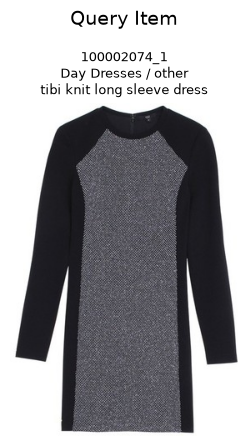

,item_ID,outfit_ID,item_position,category,broad_category,query_category,text
0,100002074_1,100002074,1,Day Dresses,other,dresses,tibi knit long sleeve dress



Baseline recommendations:


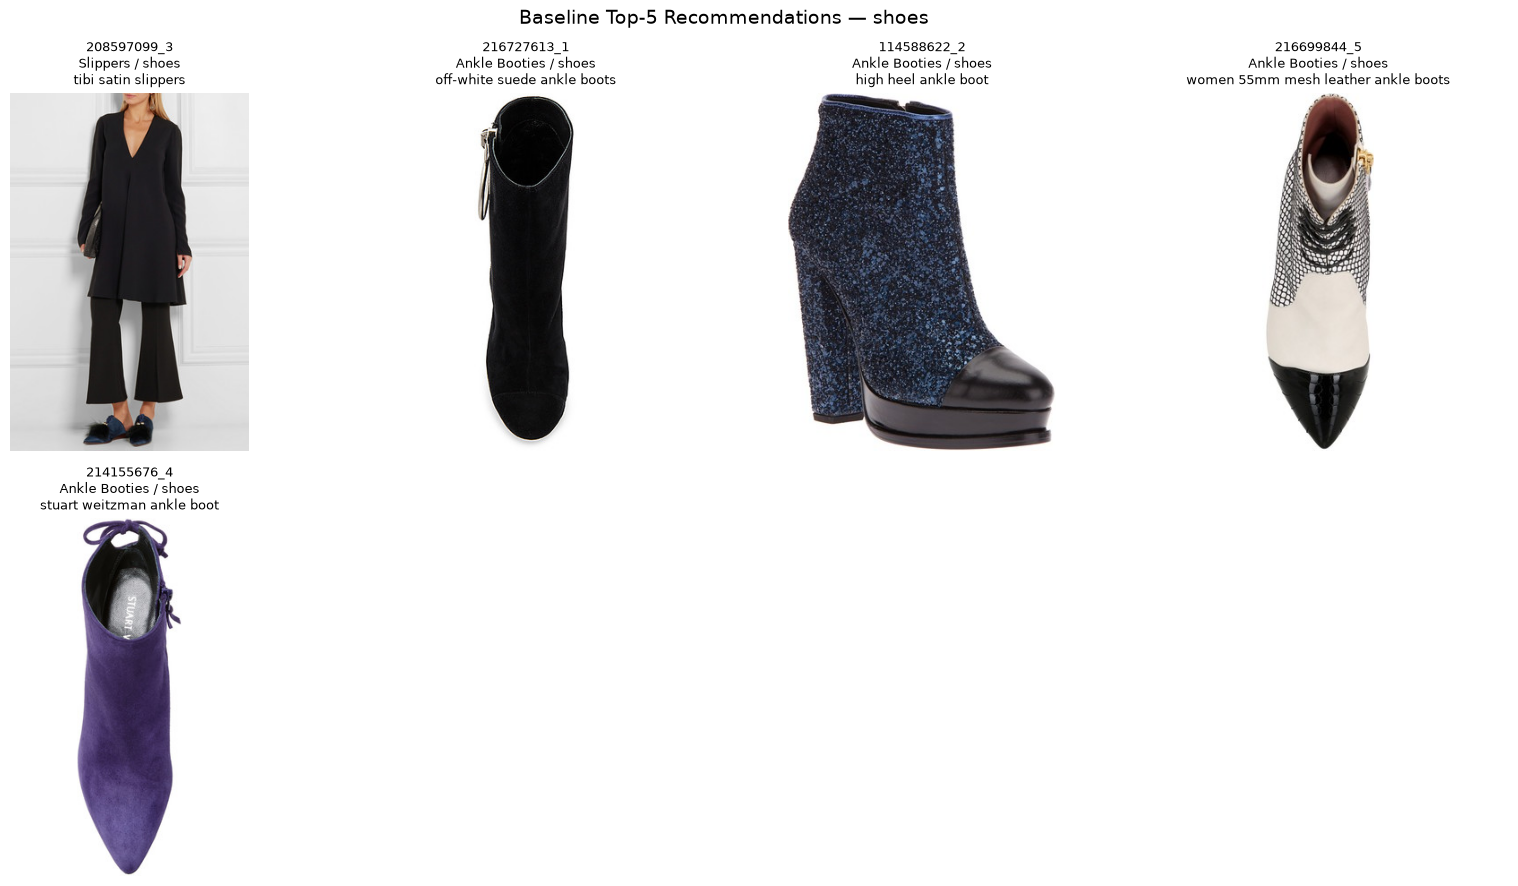

,item_ID,outfit_ID,item_position,category,broad_category,text
0,208597099_3,208597099,3,Slippers,shoes,tibi satin slippers
1,216727613_1,216727613,1,Ankle Booties,shoes,off-white suede ankle boots
2,114588622_2,114588622,2,Ankle Booties,shoes,high heel ankle boot
3,216699844_5,216699844,5,Ankle Booties,shoes,women 55mm mesh leather ankle boots
4,214155676_4,214155676,4,Ankle Booties,shoes,stuart weitzman ankle boot


,item_ID,outfit_ID,category,broad_category,text,embedding_score
0,208597099_3,208597099,Slippers,shoes,tibi satin slippers,0.809346
1,216727613_1,216727613,Ankle Booties,shoes,off-white suede ankle boots,0.800151
2,114588622_2,114588622,Ankle Booties,shoes,high heel ankle boot,0.793323
3,216699844_5,216699844,Ankle Booties,shoes,women 55mm mesh leather ankle boots,0.790677
4,214155676_4,214155676,Ankle Booties,shoes,stuart weitzman ankle boot,0.789202


In [39]:
# Cell 36: Multimodal baseline retrieval and comparison
# RUN EVERY SESSION AFTER CLIP MULTIMODAL INDEXES ARE BUILT

def retrieve_clip_multimodal_recommendations(
    query_item_id=None,
    user_text="",
    target_category="shoes",
    top_k=5,
    exclude_same_outfit=True,
):
    """
    Retrieve top-K recommendations using fused CLIP multimodal embeddings.
    """
    if target_category not in clip_multimodal_category_indexes:
        raise ValueError(
            f"Unknown target_category={target_category}. "
            f"Available categories: {list(clip_multimodal_category_indexes.keys())}"
        )
    
    query_item_row = None
    
    if query_item_id is not None:
        query_item_row = get_query_item_by_id(query_item_id)
    
    query_text, query_embedding = build_clip_multimodal_query_embedding(
        query_item_row=query_item_row,
        user_text=user_text,
        target_category=target_category,
        alpha_image_query=0.6,
        alpha_text_query=0.4,
    )
    
    search_k = min(top_k * 20, clip_multimodal_category_indexes[target_category].ntotal)
    
    scores, local_indices = clip_multimodal_category_indexes[target_category].search(
        query_embedding,
        search_k
    )
    
    global_rows = clip_multimodal_category_row_lookup[target_category][local_indices[0]]
    
    results = target_items_for_clip.iloc[global_rows].copy()
    results["clip_multimodal_score"] = scores[0]
    
    if query_item_row is not None:
        results = results[results["item_ID"] != query_item_row["item_ID"]]
        
        if exclude_same_outfit:
            results = results[results["outfit_ID"] != query_item_row["outfit_ID"]]
    
    results = results.head(top_k).reset_index(drop=True)
    
    return {
        "query_text": query_text,
        "query_item": query_item_row,
        "target_category": target_category,
        "results": results,
    }


clip_multimodal_test = retrieve_clip_multimodal_recommendations(
    query_item_id="100002074_1",
    user_text="recommend smart casual shoes",
    target_category="shoes",
    top_k=5,
)

print("Text-only baseline:")
display(
    baseline_test["results"][
        ["item_ID", "outfit_ID", "category", "broad_category", "text", "embedding_score"]
    ]
)

print("\nCLIP multimodal baseline:")
display(
    clip_multimodal_test["results"][
        ["item_ID", "outfit_ID", "category", "broad_category", "text", "clip_multimodal_score"]
    ]
)

print("\nVisual CLIP multimodal recommendations:")
display_baseline_recommendation_result(
    {
        "query_text": clip_multimodal_test["query_text"],
        "query_item": clip_multimodal_test["query_item"],
        "target_category": clip_multimodal_test["target_category"],
        "results": clip_multimodal_test["results"].rename(
            columns={"clip_multimodal_score": "embedding_score"}
        ),
    },
    max_items=5
)

In [40]:
# Cell 37: Multi-category CLIP recommendation function
# RUN EVERY SESSION AFTER CELL 36

def retrieve_clip_multimodal_multi_category(
    query_item_id=None,
    user_text="",
    target_categories=None,
    top_k_per_category=5,
    exclude_same_outfit=True,
):
    """
    Retrieve CLIP multimodal recommendations for one or more target categories.
    """
    if target_categories is None:
        target_categories = ["shoes"]
    
    all_results = []
    query_item_row = None
    
    if query_item_id is not None:
        query_item_row = get_query_item_by_id(query_item_id)
    
    for target_category in target_categories:
        retrieval_result = retrieve_clip_multimodal_recommendations(
            query_item_id=query_item_id,
            user_text=user_text,
            target_category=target_category,
            top_k=top_k_per_category,
            exclude_same_outfit=exclude_same_outfit,
        )
        
        category_results = retrieval_result["results"].copy()
        category_results["requested_target_category"] = target_category
        category_results["query_text"] = retrieval_result["query_text"]
        
        all_results.append(category_results)
    
    combined_results = pd.concat(all_results, ignore_index=True)
    
    return {
        "query_item": query_item_row,
        "user_text": user_text,
        "target_categories": target_categories,
        "results": combined_results,
    }


multi_category_test = retrieve_clip_multimodal_multi_category(
    query_item_id="100002074_1",
    user_text="recommend a jacket and accessories for a smart casual look",
    target_categories=["outerwear", "accessories"],
    top_k_per_category=3,
)

print("Query item:")
display(
    pd.DataFrame([multi_category_test["query_item"]])[
        ["item_ID", "outfit_ID", "category", "query_category", "text"]
    ]
)

print("\nMulti-category CLIP results:")
display(
    multi_category_test["results"][
        [
            "requested_target_category",
            "item_ID",
            "outfit_ID",
            "category",
            "broad_category",
            "text",
            "clip_multimodal_score",
        ]
    ]
)

Query item:


,item_ID,outfit_ID,category,query_category,text
0,100002074_1,100002074,Day Dresses,dresses,tibi knit long sleeve dress



Multi-category CLIP results:


,requested_target_category,item_ID,outfit_ID,category,broad_category,text,clip_multimodal_score
0,outerwear,187780068_2,187780068,Coats,outerwear,sheer lace plain long sleeve collarless longline coat,0.873191
1,outerwear,215355766_2,215355766,Coats,outerwear,mother pearl oversized embellished bonded wool coat,0.864363
2,outerwear,176626573_2,176626573,Coats,outerwear,joseph stretch wool-blend coat,0.863354
3,accessories,197775282_6,197775282,Scarves,accessories,contrast trim shawl,0.792324
4,accessories,175317298_4,175317298,Scarves,accessories,grey woven fringed wrap,0.777209
5,accessories,215058460_7,215058460,Scarves,accessories,weekend max mara cashmere scarf,0.774369
